# Tải các package cần thiết

CẦN INSTALL CÁC PACKKAGE ĐÚNG VERSION
=> Chạy lần lượt các lệnh sau, mỗi lần chạy xong 1 lệnh thì restart session
-------------------------------------------------------------------------------------------
pip uninstall numpy pandas scikit-learn matplotlib seaborn xgboost thinc spacy -y
pip install --no-cache-dir numpy==1.26.4
<!-- pip install --no-cache-dir pmdarima==2.0.4 -->
pip install --no-cache-dir pandas scikit-learn matplotlib seaborn xgboost
-------------------------------------------------------------------------------------------

In [1]:
import pandas as pd
import numpy as np
import re
import calendar
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import xgboost as xgb

import statsmodels.api as sm
from statsmodels.formula.api import ols

# 1: Nạp data

In [2]:
try:
    df = pd.read_csv('cleaned_order_history.csv')
except UnicodeDecodeError:
    try:
        df = pd.read_csv('cleaned_order_history.csv', encoding='latin1')
    except Exception as e:
        print(f"Lỗi khi đọc file CSV: {e}")
        exit()

df.columns = df.columns.str.strip()

print("--- Thông tin cơ bản về dữ liệu ---")
df.info()

--- Thông tin cơ bản về dữ liệu ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21321 entries, 0 to 21320
Data columns (total 26 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Restaurant ID                                       21321 non-null  int64  
 1   Restaurant name                                     21321 non-null  object 
 2   Subzone                                             21321 non-null  object 
 3   City                                                21321 non-null  object 
 4   Order ID                                            21321 non-null  int64  
 5   Order Placed At                                     21321 non-null  object 
 6   Order Status                                        21321 non-null  object 
 7   Delivery                                            21321 non-null  object 
 8   Distance                                

## 1.1 Thống kê mô tả cho các cột số

In [3]:
print("\n--- Thống kê mô tả cho các cột số ---")
numeric_cols = df.select_dtypes(include=np.number).columns
print(df[numeric_cols].describe())


--- Thống kê mô tả cho các cột số ---
       Restaurant ID      Order ID      Distance  Bill subtotal  \
count   2.132100e+04  2.132100e+04  21321.000000   21321.000000   
mean    2.074413e+07  6.354622e+09      4.167511     750.076838   
std     2.447193e+05  1.230263e+08      2.994672     498.759428   
min     2.032061e+07  6.086767e+09      0.500000      50.000000   
25%     2.063570e+07  6.250751e+09      2.000000     459.000000   
50%     2.065987e+07  6.357715e+09      3.000000     629.000000   
75%     2.088265e+07  6.456827e+09      6.000000     899.000000   
max     2.152306e+07  6.573392e+09     21.000000   16080.000000   

       Packaging charges  Restaurant discount (Promo)  \
count       21321.000000                 21321.000000   
mean           32.564592                    65.091816   
std            22.235898                    85.401604   
min             0.000000                     0.000000   
25%            18.450000                     0.000000   
50%            

# 2: Tiền xử lý dữ liệu (riêng cho promotion_impact)

In [4]:
# Chuẩn hóa các loại % off
def clean_discount(text):
    if isinstance(text, str):
        if '%' in text and 'off upto' in text:
            return 'Percentage Off with Cap'
        elif 'Flat' in text and 'off' in text:
            return 'Flat Off'
        elif text == 'No Discount':
            return 'No Discount'
        elif 'Buy' in text and 'Get' in text:
            return 'Buy X Get Y'
    return 'Other/Unknown'

df['Discount Category'] = df['Discount construct'].apply(clean_discount)
print("\n--- Các loại Discount Category sau khi gom nhóm ---")
print(df['Discount Category'].value_counts())


--- Các loại Discount Category sau khi gom nhóm ---
Discount Category
Flat Off                   5925
Other/Unknown              5500
Percentage Off with Cap    5275
Buy X Get Y                4621
Name: count, dtype: int64


# 3: Visualize to get insight

## 3.1: Trực quan phân tích hiệu quả kinh doanh theo từng loại khuyến mãi

--- Bước 1: Tổng hợp dữ liệu theo Loại Khuyến Mãi ---
Bảng tổng hợp hiệu quả theo Loại Khuyến Mãi:
         Discount Category  Số lượng đơn hàng  Tổng Doanh thu (Total)  \
1                 Flat Off               5925            5,419,492.12   
2            Other/Unknown               5500            3,836,633.69   
3  Percentage Off with Cap               5275            2,344,646.72   
0              Buy X Get Y               4621            2,953,285.61   

   Tổng Giá trị hàng hóa (Subtotal)  Tổng Chi phí Discount  Tổng Phí Đóng gói  \
1                      6,105,667.32             944,387.79         258,212.43   
2                      4,317,238.99             664,315.55         183,710.23   
3                      2,756,828.99             523,936.63         111,754.36   
0                      2,812,652.96                   0.00         140,632.65   

   AOV (Average Total)  Average Bill Subtotal  Average Discount per Order  \
1               914.68               1,030.49       

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_181664\2935734907.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0, 0], x='Discount Category', y='Số lượng đơn hàng', data=agg_df, palette='Blues_d')
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_181664\2935734907.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0, 1], x='Discount Category', y='Tổng Doanh thu (Total)', data=agg_df, palette='Greens_d')
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_181664\2935734907.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1,

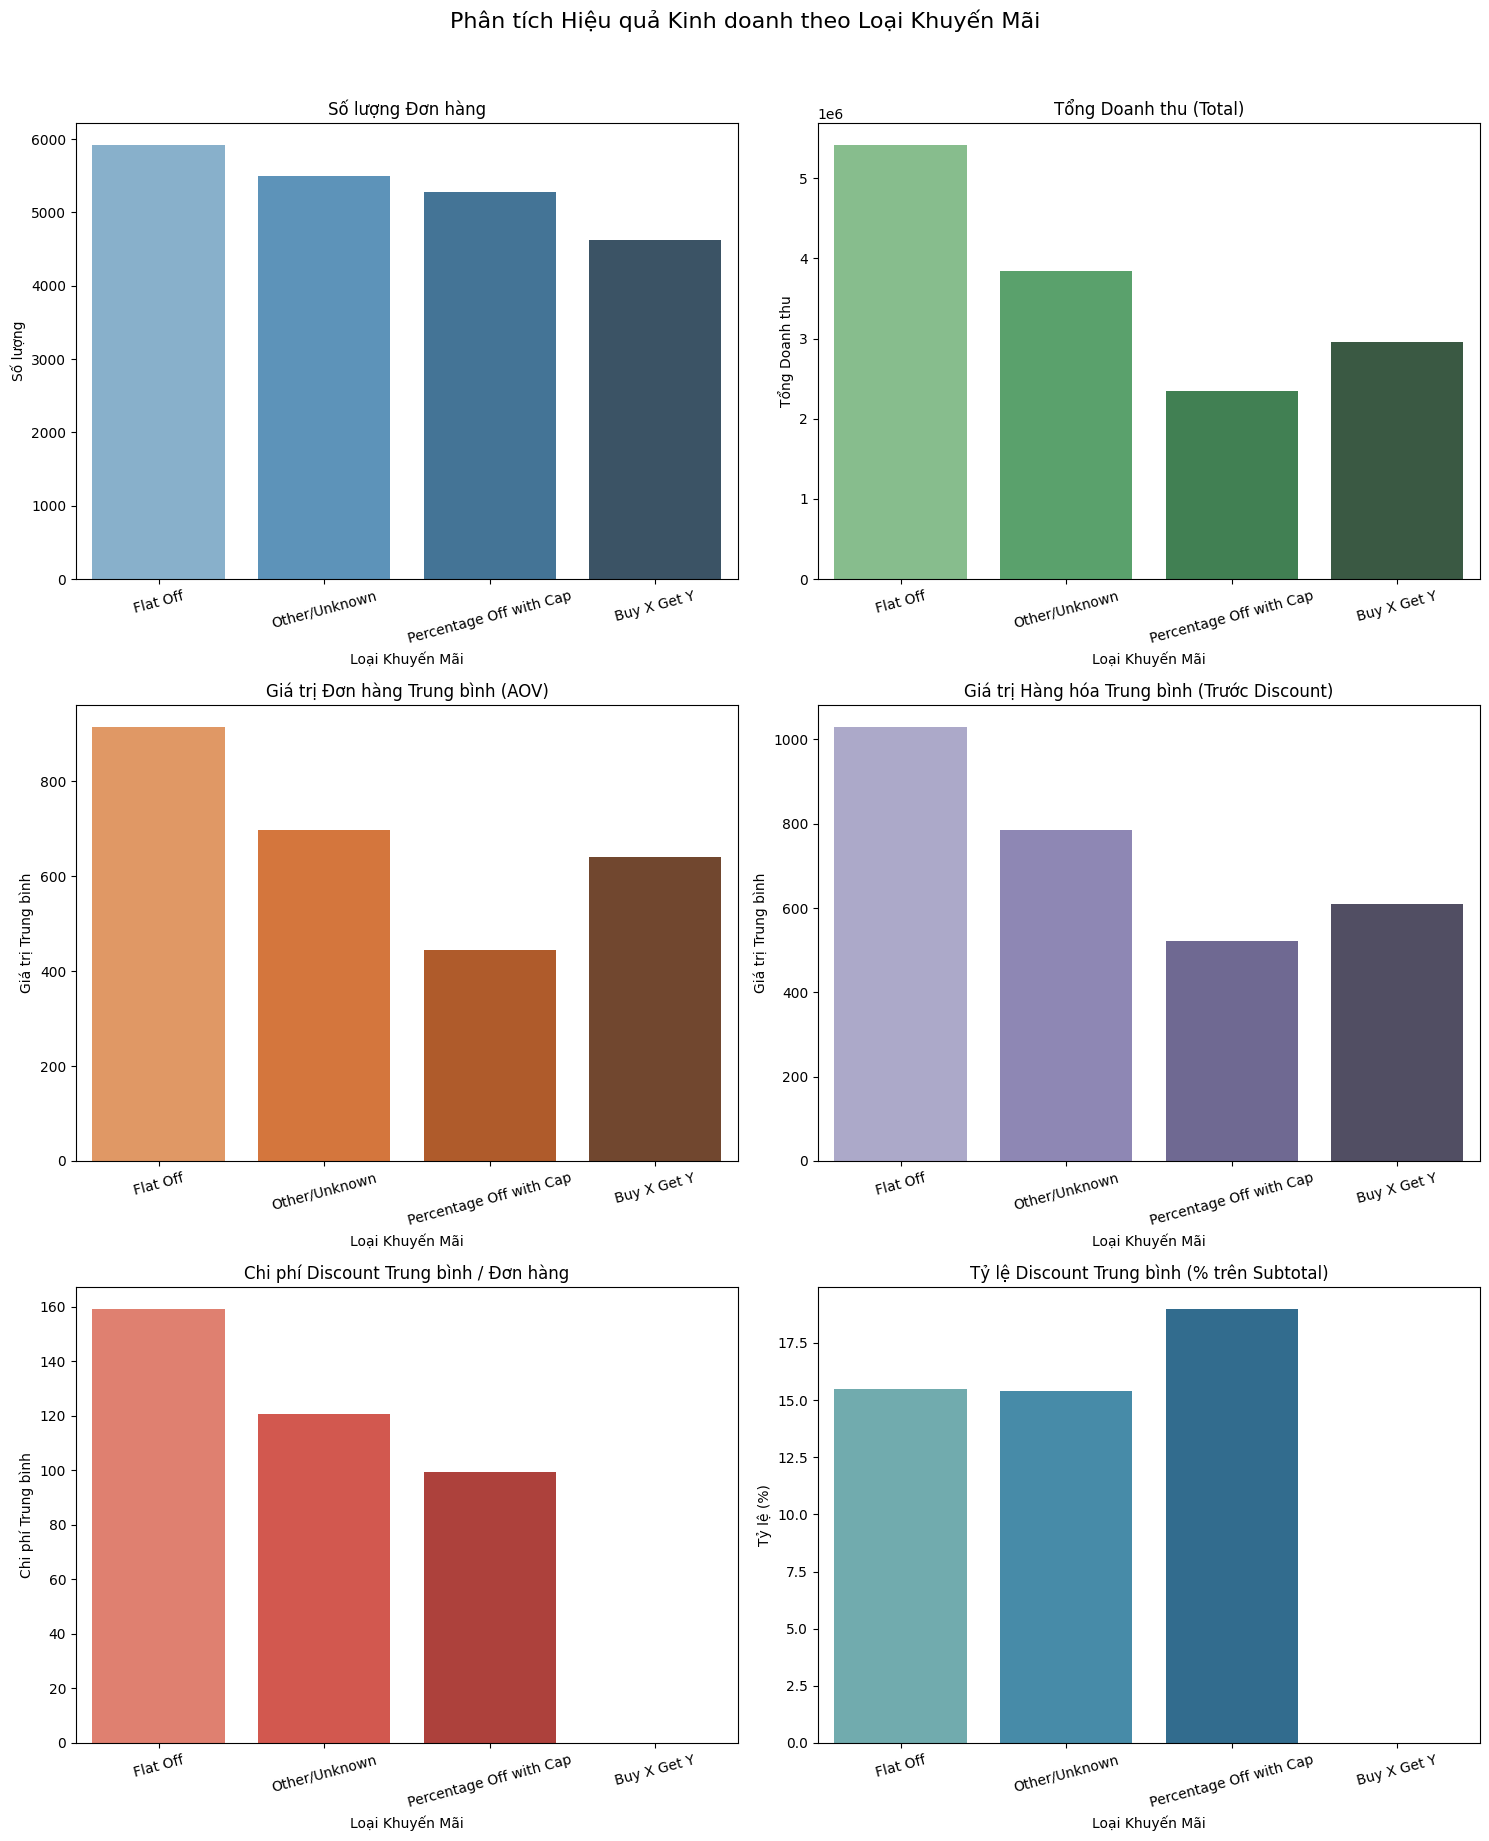

In [5]:
# Bước 1: Tổng hợp dữ liệu theo Discount Category
print("--- Bước 1: Tổng hợp dữ liệu theo Loại Khuyến Mãi ---")

# Tính tổng chi phí giảm giá số cho mỗi đơn hàng
discount_cols_numeric = [
    'Restaurant discount (Promo)',
    'Restaurant discount (Flat offs, Freebies & others)',
    'Gold discount',
    'Brand pack discount'
]
df['Total Numerical Discount Cost'] = df[discount_cols_numeric].sum(axis=1)

# Tổng hợp dữ liệu
agg_metrics = {
    'Order ID': ('Order ID', 'count'),
    'Total': ('Total', 'sum'),
    'Bill subtotal': ('Bill subtotal', 'sum'),
    'Total Numerical Discount Cost': ('Total Numerical Discount Cost', 'sum'),
    'Packaging charges': ('Packaging charges', 'sum')
}

agg_df = df.groupby('Discount Category').agg(**agg_metrics).reset_index()

# Đổi tên cột
agg_df.rename(columns={
    'Order ID': 'Số lượng đơn hàng',
    'Total': 'Tổng Doanh thu (Total)',
    'Bill subtotal': 'Tổng Giá trị hàng hóa (Subtotal)',
    'Total Numerical Discount Cost': 'Tổng Chi phí Discount',
    'Packaging charges': 'Tổng Phí Đóng gói'
}, inplace=True)

# Tính toán các chỉ số trung bình và tỷ lệ
agg_df['AOV (Average Total)'] = agg_df['Tổng Doanh thu (Total)'] / agg_df['Số lượng đơn hàng']
agg_df['Average Bill Subtotal'] = agg_df['Tổng Giá trị hàng hóa (Subtotal)'] / agg_df['Số lượng đơn hàng']
agg_df['Average Discount per Order'] = agg_df['Tổng Chi phí Discount'] / agg_df['Số lượng đơn hàng']
agg_df['Average Discount % (of Subtotal)'] = np.where(
    agg_df['Tổng Giá trị hàng hóa (Subtotal)'] > 0,
    (agg_df['Tổng Chi phí Discount'] / agg_df['Tổng Giá trị hàng hóa (Subtotal)']) * 100,
    0
)

# Sắp xếp theo số lượng đơn hàng
agg_df = agg_df.sort_values(by='Số lượng đơn hàng', ascending=False)

# Hiển thị bảng tổng hợp
print("Bảng tổng hợp hiệu quả theo Loại Khuyến Mãi:")
pd.options.display.float_format = '{:,.2f}'.format
print(agg_df)
print("-" * 70)

# Bước 2: Trực quan hóa kết quả tổng hợp
print("\n--- Bước 2: Trực quan hóa Hiệu quả theo Loại Khuyến Mãi ---")

# Tạo subplot
fig, axes = plt.subplots(3, 2, figsize=(15, 18))
fig.suptitle('Phân tích Hiệu quả Kinh doanh theo Loại Khuyến Mãi', fontsize=16, y=1.02)

# 1. Số lượng đơn hàng
sns.barplot(ax=axes[0, 0], x='Discount Category', y='Số lượng đơn hàng', data=agg_df, palette='Blues_d')
axes[0, 0].set_title('Số lượng Đơn hàng')
axes[0, 0].set_xlabel('Loại Khuyến Mãi')
axes[0, 0].set_ylabel('Số lượng')
axes[0, 0].tick_params(axis='x', rotation=15)

# 2. Tổng Doanh thu (Total)
sns.barplot(ax=axes[0, 1], x='Discount Category', y='Tổng Doanh thu (Total)', data=agg_df, palette='Greens_d')
axes[0, 1].set_title('Tổng Doanh thu (Total)')
axes[0, 1].set_xlabel('Loại Khuyến Mãi')
axes[0, 1].set_ylabel('Tổng Doanh thu')
axes[0, 1].tick_params(axis='x', rotation=15)

# 3. AOV (Average Total)
sns.barplot(ax=axes[1, 0], x='Discount Category', y='AOV (Average Total)', data=agg_df, palette='Oranges_d')
axes[1, 0].set_title('Giá trị Đơn hàng Trung bình (AOV)')
axes[1, 0].set_xlabel('Loại Khuyến Mãi')
axes[1, 0].set_ylabel('Giá trị Trung bình')
axes[1, 0].tick_params(axis='x', rotation=15)

# 4. Average Bill Subtotal
sns.barplot(ax=axes[1, 1], x='Discount Category', y='Average Bill Subtotal', data=agg_df, palette='Purples_d')
axes[1, 1].set_title('Giá trị Hàng hóa Trung bình (Trước Discount)')
axes[1, 1].set_xlabel('Loại Khuyến Mãi')
axes[1, 1].set_ylabel('Giá trị Trung bình')
axes[1, 1].tick_params(axis='x', rotation=15)

# 5. Average Discount per Order
sns.barplot(ax=axes[2, 0], x='Discount Category', y='Average Discount per Order', data=agg_df, palette='Reds_d')
axes[2, 0].set_title('Chi phí Discount Trung bình / Đơn hàng')
axes[2, 0].set_xlabel('Loại Khuyến Mãi')
axes[2, 0].set_ylabel('Chi phí Trung bình')
axes[2, 0].tick_params(axis='x', rotation=15)

# 6. Average Discount % (of Subtotal)
sns.barplot(ax=axes[2, 1], x='Discount Category', y='Average Discount % (of Subtotal)', data=agg_df, palette='YlGnBu_d')
axes[2, 1].set_title('Tỷ lệ Discount Trung bình (% trên Subtotal)')
axes[2, 1].set_xlabel('Loại Khuyến Mãi')
axes[2, 1].set_ylabel('Tỷ lệ (%)')
axes[2, 1].tick_params(axis='x', rotation=15)

# Điều chỉnh layout và hiển thị
plt.tight_layout()
plt.show()

## 3.2: Số lượng Khách hàng Khác nhau theo Loại Khuyến Mãi & Phân phối Tần suất Đặt hàng của Khách hàng


--- 3.3: Phân tích Khách hàng Cơ bản ---

--- Số lượng Khách hàng Duy nhất theo Loại Khuyến Mãi ---
Discount Category
Flat Off                   4092
Percentage Off with Cap    3896
Other/Unknown              3828
Buy X Get Y                3342
Name: Customer ID, dtype: int64


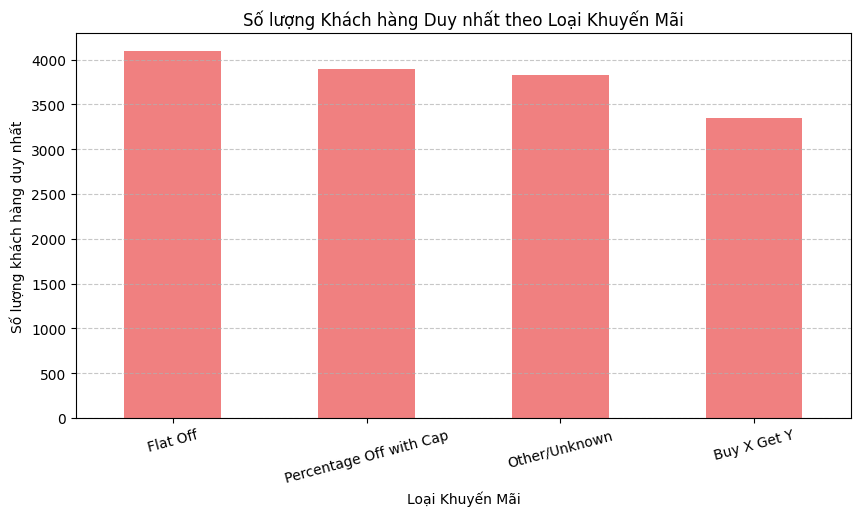


--- Phân phối Tần suất Đặt hàng của Khách hàng ---
Thống kê mô tả:
count   11,607.00
mean         1.84
std          2.03
min          1.00
25%          1.00
50%          1.00
75%          2.00
max         61.00
Name: count, dtype: float64

Số lượng khách hàng theo Tần suất đặt hàng:
count
1     7713
2     1906
3      824
4      435
5      254
6      134
7      106
8       59
9       48
10      33
11      22
12      19
13       8
14       5
15       8
16       3
17       2
18       3
19       4
20       4
21       5
22       1
23       1
24       1
28       2
29       3
31       2
38       1
61       1


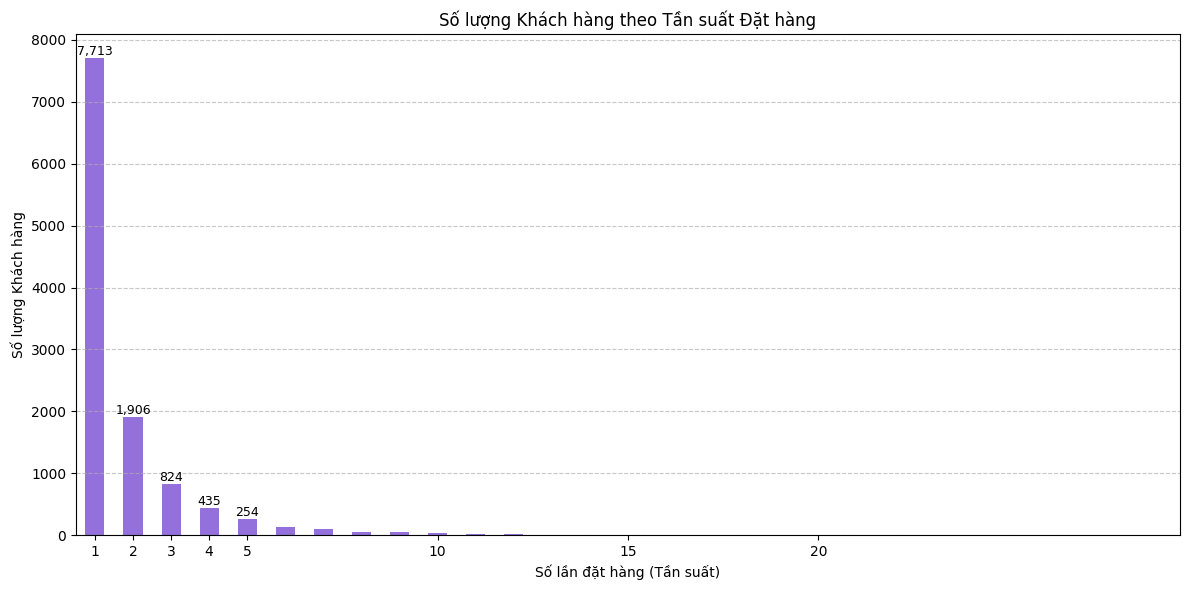


Trong tập dữ liệu này, có 11607 khách hàng khác nhau.
Khách hàng đặt nhiều đơn nhất đã đặt: 61 đơn.
Số khách hàng chỉ đặt 1 đơn: 7713.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 3.3: Phân tích Khách hàng cơ bản ---
print("\n--- 3.3: Phân tích Khách hàng Cơ bản ---")

# Đảm bảo cột 'Customer ID' tồn tại
if 'Customer ID' not in df.columns:
     print("Lỗi: Không tìm thấy cột 'Customer ID'. Bỏ qua phân tích khách hàng.")
else:
    # Số lượng khách hàng khác nhau sử dụng từng loại khuyến mãi
    if 'Discount Category' in df.columns:
        print("\n--- Số lượng Khách hàng Duy nhất theo Loại Khuyến Mãi ---")
        customers_per_discount = df.groupby('Discount Category')['Customer ID'].nunique().sort_values(ascending=False)
        print(customers_per_discount)

        plt.figure(figsize=(10, 5))
        customers_per_discount.plot(kind='bar', color='lightcoral')
        plt.title('Số lượng Khách hàng Duy nhất theo Loại Khuyến Mãi')
        plt.xlabel('Loại Khuyến Mãi')
        plt.ylabel('Số lượng khách hàng duy nhất')
        plt.xticks(rotation=15)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()
    else:
        print("\nCảnh báo: Không tìm thấy cột 'Discount Category'. Bỏ qua phân tích khách hàng theo loại KM.")


    # Phân tích tần suất đặt hàng của khách hàng (số lần mỗi khách đặt hàng)
    customer_frequency = df['Customer ID'].value_counts()
    print("\n--- Phân phối Tần suất Đặt hàng của Khách hàng ---")
    print("Thống kê mô tả:")
    print(customer_frequency.describe().round(2)) # Xem thống kê mô tả tần suất


    # Cách trực quan hóa mới: Đếm số lượng khách hàng cho mỗi mức tần suất cụ thể
    frequency_counts = customer_frequency.value_counts().sort_index()

    # Hiển thị bảng các tần suất và số lượng khách tương ứng
    print("\nSố lượng khách hàng theo Tần suất đặt hàng:")
    print(frequency_counts.to_string()) # Dùng to_string để in đầy đủ nếu nhiều dòng

    # Trực quan hóa số lượng khách hàng theo tần suất
    plt.figure(figsize=(12, 6)) # Tăng chiều rộng cho dễ nhìn
    # Sử dụng bar plot trực tiếp trên Series frequency_counts
    ax = frequency_counts.plot(kind='bar', color='mediumpurple')

    plt.title('Số lượng Khách hàng theo Tần suất Đặt hàng')
    plt.xlabel('Số lần đặt hàng (Tần suất)')
    plt.ylabel('Số lượng Khách hàng')

    # Điều chỉnh trục X để hiển thị các tần suất hợp lý hơn
    # Hiển thị tick cho một số tần suất đầu và có thể cách quãng cho tần suất cao hơn
    max_freq_in_counts = frequency_counts.index.max()
    # Chọn tick cho các tần suất nhỏ (ví dụ: 1, 2, 3, 4, 5) và sau đó cách quãng (ví dụ: mỗi 5 hoặc 10 đơn vị)
    if max_freq_in_counts <= 10:
         tick_positions = range(1, max_freq_in_counts + 1)
    elif max_freq_in_counts <= 20:
         tick_positions = list(range(1, 6)) + list(range(10, max_freq_in_counts + 1, 5))
    else:
         tick_positions = list(range(1, 6)) + list(range(10, 20, 5)) + list(range(20, max_freq_in_counts + 1, 10))

    # Đảm bảo tick positions chỉ chứa các tần suất thực sự có trong dữ liệu
    tick_positions = [freq for freq in tick_positions if freq in frequency_counts.index]

    plt.xticks(rotation=0) # Giữ nhãn thẳng
    ax.set_xticks(frequency_counts.index.get_indexer(tick_positions)) # Đặt vị trí tick
    ax.set_xticklabels(tick_positions) # Đặt nhãn cho tick


    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Thêm annotation cho một số cột đầu hoặc các cột quan trọng (tần suất cao)
    # Chỉ thêm annotation cho các tần suất nhỏ hơn để tránh quá tải biểu đồ
    annotations_to_show = frequency_counts[frequency_counts.index <= 5] # Ví dụ: Chỉ hiển thị annotation cho tần suất 1 đến 5
    # Nếu có rất ít tần suất, hiển thị hết
    if len(frequency_counts) <= 10:
         annotations_to_show = frequency_counts

    for freq, count in annotations_to_show.items():
         if count > 0: # Chỉ annotate nếu số khách hàng > 0
              # Tìm vị trí x của cột tương ứng với tần suất này
              x_pos = frequency_counts.index.get_loc(freq)
              ax.text(x_pos, count, f'{count:,}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout() # Tự động điều chỉnh layout

    plt.show()


    print(f"\nTrong tập dữ liệu này, có {df['Customer ID'].nunique()} khách hàng khác nhau.")
    if not customer_frequency.empty:
        print(f"Khách hàng đặt nhiều đơn nhất đã đặt: {customer_frequency.max():.0f} đơn.")
        print(f"Số khách hàng chỉ đặt 1 đơn: {sum(customer_frequency == 1):.0f}.")
    else:
        print("Không có dữ liệu tần suất khách hàng.")


# else:
#     print("Dữ liệu gốc rỗng hoặc không có cột 'Customer ID'. Bỏ qua phân tích khách hàng.")


# print("-" * 70)

# 4: Phân tích ANOVA

---


- Xem xét liệu có sự khác biệt đáng kể về mặt thống kê trong giá trị trung bình của 'Total' giữa các nhóm 'Discount Category' khác nhau hay không

In [7]:
print("\nĐang tạo df_anova bằng cách lọc các category có ít nhất 2 đơn hàng...")
category_counts_full = df['Discount Category'].value_counts()
valid_categories_full = category_counts_full[category_counts_full >= 2].index.tolist()
df_anova = df[df['Discount Category'].isin(valid_categories_full)].copy()

print(f"\nTổng số dòng trong df_anova sau khi lọc: {len(df_anova)}")
print(f"Các Discount Category còn lại trong df_anova: {df_anova['Discount Category'].unique().tolist()}")

print("\n--- Thực hiện phân tích ANOVA trên 'Total' theo 'Discount Category' ---")

model_anova_total = ols('Total ~ C(Q("Discount Category"))', data=df_anova).fit()
anova_table_total = sm.stats.anova_lm(model_anova_total, typ=2)

print("\nBảng kết quả ANOVA:")
print(anova_table_total)

try:
    p_value_total = anova_table_total.loc['C(Q("Discount Category"))', 'PR(>F)']
except KeyError:
    if not anova_table_total.empty and 'PR(>F)' in anova_table_total.columns:
        p_value_total = anova_table_total.iloc[0]['PR(>F)']
    else:
        print("\nLỗi: Không tìm thấy p-value trong bảng ANOVA. Vui lòng kiểm tra cấu trúc bảng.")
        p_value_total = float('nan')

print(f"\nKết luận từ ANOVA:")
if p_value_total < 0.05:
    print(f"P-value ({p_value_total:.4f}) < 0.05.")
    print("-> Có sự khác biệt đáng kể về mặt thống kê trong giá trị Total TRUNG BÌNH giữa ít nhất một cặp nhóm khuyến mãi.")
else:
    print(f"P-value ({p_value_total:.4f}) >= 0.05.")
    print("-> Không có đủ bằng chứng cho thấy sự khác biệt đáng kể về mặt thống kê trong giá trị Total TRUNG BÌNH giữa các nhóm khuyến mãi trong tập dữ liệu này.")

print("---------------------------------------------------------------------------")



Đang tạo df_anova bằng cách lọc các category có ít nhất 2 đơn hàng...

Tổng số dòng trong df_anova sau khi lọc: 21321
Các Discount Category còn lại trong df_anova: ['Percentage Off with Cap', 'Flat Off', 'Other/Unknown', 'Buy X Get Y']

--- Thực hiện phân tích ANOVA trên 'Total' theo 'Discount Category' ---

Bảng kết quả ANOVA:
                                    sum_sq        df        F  PR(>F)
C(Q("Discount Category"))   628,200,942.55      3.00 1,119.32    0.00
Residual                  3,987,943,574.34 21,317.00      NaN     NaN

Kết luận từ ANOVA:
P-value (0.0000) < 0.05.
-> Có sự khác biệt đáng kể về mặt thống kê trong giá trị Total TRUNG BÌNH giữa ít nhất một cặp nhóm khuyến mãi.
---------------------------------------------------------------------------


# 5: Xem insight chi tiết về Per/Cap


--- Phân tích Hiệu quả và Khoảng thời gian của từng Loại KM Percentage Off cụ thể ---

Đang phân tích các loại khuyến mãi cụ thể trong nhóm 'Percentage Off with Cap'.

Bảng tổng hợp hiệu quả và khoảng thời gian của các loại KM 'Percentage Off with Cap':
    Discount construct First_Order_Date_Str Last_Order_Date_Str  Total_Orders  \
3  50% off upto Rs.100           2024-09-01          2025-01-31          3561   
4  60% off upto Rs.120           2024-09-01          2025-01-31          1102   
2   40% off upto Rs.80           2024-09-01          2024-11-29           572   
0   20% off upto Rs.50           2024-09-01          2024-10-27            34   
1   30% off upto Rs.75           2024-09-21          2024-12-14             6   

   Total_Discount_Cost  Total_Revenue  Average_Bill_Subtotal  \
3           364,829.08   1,706,631.46                 558.86   
4           110,281.69     397,779.68                 443.85   
2            46,200.40     223,940.83                 453.60   
0 

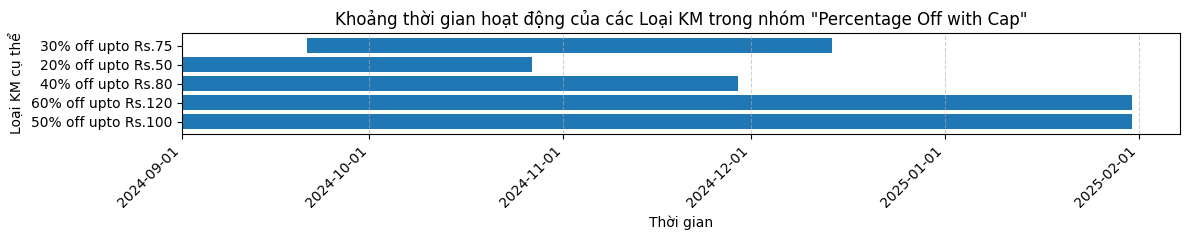


Giải thích Biểu đồ Khoảng thời gian:
- Mỗi thanh ngang biểu thị một loại KM cụ thể trong nhóm 'Percentage Off with Cap'.
- Chiều dài của thanh thể hiện khoảng thời gian từ đơn hàng đầu tiên đến đơn hàng cuối cùng sử dụng loại KM đó.
----------------------------------------------------------------------

--- Phân tích Tương quan của Percentage/Cap với Doanh thu và Chi phí ---

Ma trận tương quan:
                               Percentage   Cap  Total  \
Percentage                           1.00  1.00  -0.07   
Cap                                  1.00  1.00  -0.07   
Total                               -0.07 -0.07   1.00   
Total Numerical Discount Cost        0.14  0.14   0.14   

                               Total Numerical Discount Cost  
Percentage                                              0.14  
Cap                                                     0.14  
Total                                                   0.14  
Total Numerical Discount Cost                           1

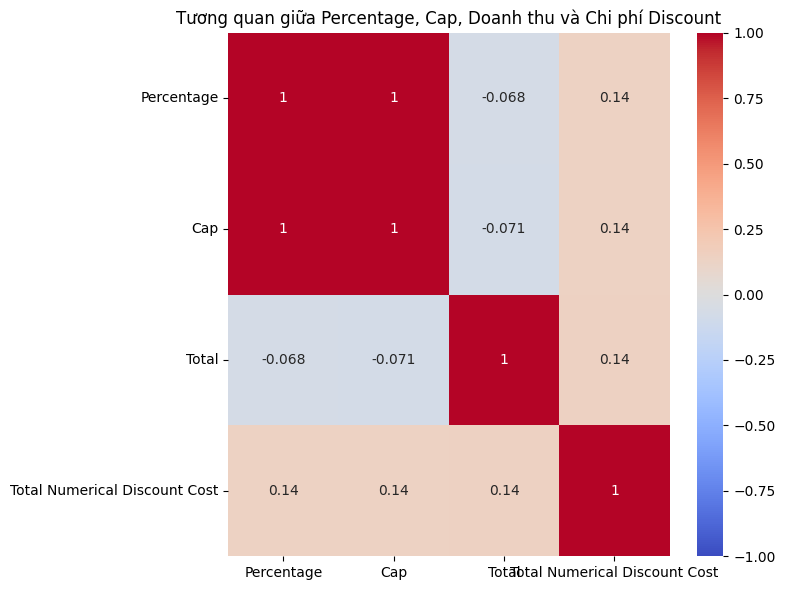

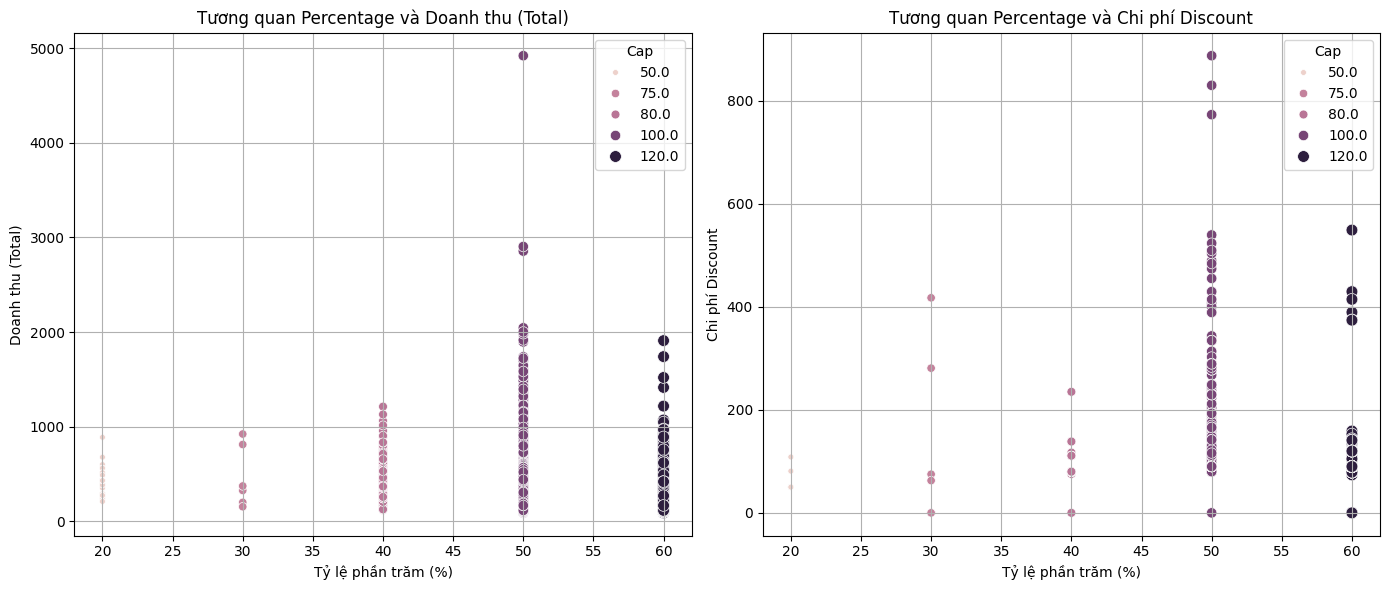


Giải thích Tương quan:
- Ma trận tương quan cho thấy mức độ liên quan giữa Percentage, Cap, Doanh thu và Chi phí.
- Scatter plot hiển thị cách Percentage ảnh hưởng đến Doanh thu/Chi phí, với kích thước và màu sắc biểu thị Cap.
- Nếu tương quan gần 1 hoặc -1, mối quan hệ mạnh; gần 0 thì yếu.
----------------------------------------------------------------------

--- Phân tích Bill Subtotal theo Loại KM Percentage Off with Cap ---


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_181664\3536916694.py:157: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_target_category, x='Bill subtotal', y='Discount construct', palette='Set2')


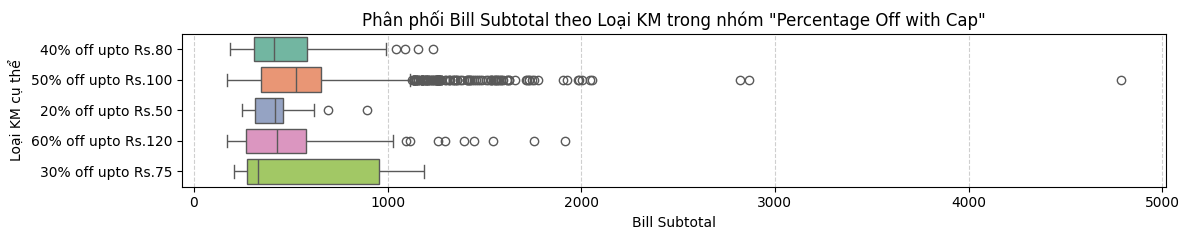


Giải thích Biểu đồ Bill Subtotal:
- Boxplot cho thấy phân phối Bill Subtotal cho từng loại KM cụ thể.
- Hộp (box) biểu thị khoảng từ Q1 đến Q3 (50% dữ liệu trung tâm).
- Đường giữa hộp là giá trị trung vị (median) của Bill Subtotal.
- Các điểm ngoài cùng (whiskers) cho thấy phạm vi dữ liệu, ngoại trừ các giá trị ngoại lai (outliers).
- Điều này giúp bạn thấy loại KM nào thường được dùng với đơn hàng có Bill Subtotal cao/thấp.
----------------------------------------------------------------------


In [8]:
# Giả định df đã được tải và tiền xử lý cơ bản
if 'DayofWeek' not in df.columns:
    df['Order Placed At'] = pd.to_datetime(df['Order Placed At'], errors='coerce')
    df.dropna(subset=['Order Placed At'], inplace=True)
    df['DayofWeek'] = df['Order Placed At'].dt.dayofweek
    df['DayofWeekName'] = df['Order Placed At'].dt.day_name()

# Đảm bảo cột 'Total Numerical Discount Cost' đã được tính
discount_cols_numeric = [
    'Restaurant discount (Promo)',
    'Restaurant discount (Flat offs, Freebies & others)',
    'Gold discount',
    'Brand pack discount'
]
valid_cols = [col for col in discount_cols_numeric if col in df.columns]
if valid_cols:
    df['Total Numerical Discount Cost'] = df[valid_cols].sum(axis=1)
else:
    print("Cảnh báo: Không tìm thấy cột discount số nào để tính 'Total Numerical Discount Cost'. Tạo cột với giá trị 0.")
    df['Total Numerical Discount Cost'] = 0

# Đảm bảo cột 'Order Placed At' và 'Order Date'
if not pd.api.types.is_datetime64_any_dtype(df['Order Placed At']):
    df['Order Placed At'] = pd.to_datetime(df['Order Placed At'], errors='coerce')
    df.dropna(subset=['Order Placed At'], inplace=True)

if 'Order Date' not in df.columns:
    df['Order Date'] = df['Order Placed At'].dt.date
    df['Order Date'] = pd.to_datetime(df['Order Date'])

# --- Phân tích Hiệu quả và Khoảng thời gian của từng Loại KM Percentage Off cụ thể ---
print("\n--- Phân tích Hiệu quả và Khoảng thời gian của từng Loại KM Percentage Off cụ thể ---")

target_promo_category = 'Percentage Off with Cap'
df_target_category = df[df['Discount Category'] == target_promo_category].copy()

if df_target_category.empty:
    print(f"Không tìm thấy dữ liệu cho nhóm khuyến mãi '{target_promo_category}' trong tập dữ liệu.")
else:
    print(f"\nĐang phân tích các loại khuyến mãi cụ thể trong nhóm '{target_promo_category}'.")

    # Hàm trích xuất Percentage và Cap từ Discount construct
    def extract_percentage_cap(discount_str):
        try:
            # Ví dụ: "40% off upto Rs.80" -> Percentage = 40, Cap = 80
            percentage_match = re.search(r'(\d+)%', discount_str)
            cap_match = re.search(r'upto Rs\.(\d+)', discount_str)
            percentage = float(percentage_match.group(1)) if percentage_match else np.nan
            cap = float(cap_match.group(1)) if cap_match else np.nan
            return percentage, cap
        except:
            return np.nan, np.nan

    # Áp dụng hàm để tạo cột Percentage và Cap
    df_target_category[['Percentage', 'Cap']] = df_target_category['Discount construct'].apply(
        lambda x: pd.Series(extract_percentage_cap(x))
    )

    # 1. Tổng hợp dữ liệu theo Discount construct
    promo_string_performance = df_target_category.groupby('Discount construct').agg(
        First_Order_Date=('Order Date', 'min'),
        Last_Order_Date=('Order Date', 'max'),
        Total_Orders=('Order ID', 'count'),
        Total_Discount_Cost=('Total Numerical Discount Cost', 'sum'),
        Total_Revenue=('Total', 'sum'),
        Average_Bill_Subtotal=('Bill subtotal', 'mean'),
        Average_Percentage=('Percentage', 'mean'),
        Average_Cap=('Cap', 'mean')
    ).reset_index()

    promo_string_performance = promo_string_performance.sort_values(by='Total_Orders', ascending=False)

    print(f"\nBảng tổng hợp hiệu quả và khoảng thời gian của các loại KM '{target_promo_category}':")
    promo_string_performance['First_Order_Date_Str'] = promo_string_performance['First_Order_Date'].dt.strftime('%Y-%m-%d')
    promo_string_performance['Last_Order_Date_Str'] = promo_string_performance['Last_Order_Date'].dt.strftime('%Y-%m-%d')
    print(promo_string_performance[['Discount construct', 'First_Order_Date_Str', 'Last_Order_Date_Str', 'Total_Orders',
                                    'Total_Discount_Cost', 'Total_Revenue', 'Average_Bill_Subtotal', 'Average_Percentage',
                                    'Average_Cap']].round(2))

    print("-" * 70)

    # --- Trực quan hóa Khoảng thời gian hoạt động ---
    print("\n--- Trực quan hóa Khoảng thời gian hoạt động của từng Loại KM cụ thể ---")
    plt.figure(figsize=(12, min(len(promo_string_performance) * 0.5, 10)))
    promo_string_performance_sorted_time = promo_string_performance.sort_values(by='First_Order_Date')
    plt.barh(
        y=promo_string_performance_sorted_time['Discount construct'],
        left=promo_string_performance_sorted_time['First_Order_Date'],
        width=(promo_string_performance_sorted_time['Last_Order_Date'] - promo_string_performance_sorted_time['First_Order_Date']),
        height=0.8
    )
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.xticks(rotation=45, ha='right')
    plt.xlabel('Thời gian')
    plt.ylabel('Loại KM cụ thể')
    plt.title(f'Khoảng thời gian hoạt động của các Loại KM trong nhóm "{target_promo_category}"')
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    print("\nGiải thích Biểu đồ Khoảng thời gian:")
    print("- Mỗi thanh ngang biểu thị một loại KM cụ thể trong nhóm 'Percentage Off with Cap'.")
    print("- Chiều dài của thanh thể hiện khoảng thời gian từ đơn hàng đầu tiên đến đơn hàng cuối cùng sử dụng loại KM đó.")
    print("-" * 70)

    # --- Phân tích Tương quan Percentage/Cap với Doanh thu và Chi phí ---
    print("\n--- Phân tích Tương quan của Percentage/Cap với Doanh thu và Chi phí ---")

    # Loại bỏ các dòng có giá trị NaN trong Percentage hoặc Cap
    df_corr = df_target_category.dropna(subset=['Percentage', 'Cap', 'Total', 'Total Numerical Discount Cost'])

    if not df_corr.empty:
        # Tính ma trận tương quan
        corr_matrix = df_corr[['Percentage', 'Cap', 'Total', 'Total Numerical Discount Cost']].corr()

        print("\nMa trận tương quan:")
        print(corr_matrix.round(2))

        # Trực quan hóa bằng heatmap
        plt.figure(figsize=(8, 6))
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
        plt.title('Tương quan giữa Percentage, Cap, Doanh thu và Chi phí Discount')
        plt.tight_layout()
        plt.show()

        # Scatter plot để xem mối quan hệ chi tiết
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        sns.scatterplot(data=df_corr, x='Percentage', y='Total', size='Cap', hue='Cap', ax=axes[0])
        axes[0].set_title('Tương quan Percentage và Doanh thu (Total)')
        axes[0].set_xlabel('Tỷ lệ phần trăm (%)')
        axes[0].set_ylabel('Doanh thu (Total)')
        axes[0].grid(True)

        sns.scatterplot(data=df_corr, x='Percentage', y='Total Numerical Discount Cost', size='Cap', hue='Cap', ax=axes[1])
        axes[1].set_title('Tương quan Percentage và Chi phí Discount')
        axes[1].set_xlabel('Tỷ lệ phần trăm (%)')
        axes[1].set_ylabel('Chi phí Discount')
        axes[1].grid(True)

        plt.tight_layout()
        plt.show()

        print("\nGiải thích Tương quan:")
        print("- Ma trận tương quan cho thấy mức độ liên quan giữa Percentage, Cap, Doanh thu và Chi phí.")
        print("- Scatter plot hiển thị cách Percentage ảnh hưởng đến Doanh thu/Chi phí, với kích thước và màu sắc biểu thị Cap.")
        print("- Nếu tương quan gần 1 hoặc -1, mối quan hệ mạnh; gần 0 thì yếu.")
    else:
        print("Không đủ dữ liệu để tính tương quan (có giá trị NaN trong Percentage hoặc Cap).")

    print("-" * 70)

    # --- Phân tích Bill Subtotal theo Discount Construct ---
    print("\n--- Phân tích Bill Subtotal theo Loại KM Percentage Off with Cap ---")

    plt.figure(figsize=(12, min(len(promo_string_performance) * 0.5, 10)))
    sns.boxplot(data=df_target_category, x='Bill subtotal', y='Discount construct', palette='Set2')
    plt.title(f'Phân phối Bill Subtotal theo Loại KM trong nhóm "{target_promo_category}"')
    plt.xlabel('Bill Subtotal')
    plt.ylabel('Loại KM cụ thể')
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    print("\nGiải thích Biểu đồ Bill Subtotal:")
    print("- Boxplot cho thấy phân phối Bill Subtotal cho từng loại KM cụ thể.")
    print("- Hộp (box) biểu thị khoảng từ Q1 đến Q3 (50% dữ liệu trung tâm).")
    print("- Đường giữa hộp là giá trị trung vị (median) của Bill Subtotal.")
    print("- Các điểm ngoài cùng (whiskers) cho thấy phạm vi dữ liệu, ngoại trừ các giá trị ngoại lai (outliers).")
    print("- Điều này giúp bạn thấy loại KM nào thường được dùng với đơn hàng có Bill Subtotal cao/thấp.")

print("-" * 70)

# 6: Kết thúc, có Elasticity

--- BẮT ĐẦU PHÂN TÍCH ẢNH HƯỞNG CỦA KHUYẾN MÃI (TẬP TRUNG VÀO ĐƠN HÀNG SUBTOTAL > 1000) ---

--- Nạp Dữ liệu ---
Dữ liệu đã được nạp thành công. Số lượng đơn hàng ban đầu: 21321

--- Chuẩn bị Dữ liệu và Tạo Đặc trưng ---
Đã chuyển 'Order Placed At' sang datetime.
Đã tạo cột 'DayofWeek' và 'DayofWeekName'.
Đã tạo cột 'Hour'.
Đã tạo cột 'Order Date'.
Đã tạo cột 'Discount Category'.
Đã tính 'Total Numerical Discount Cost'.
Đã tạo các cột 'Discount_Pct', 'Discount_Cap', 'Discount_Flat'.
Đã tạo cột 'Num_Distinct_Items'.
----------------------------------------------------------------------

--- Huấn luyện Mô hình Regression dự đoán Bill Subtotal ---
Kích thước features_regression sau loại bỏ NaN cho Regression: (21321, 8)
Kích thước target_regression sau loại bỏ NaN cho Regression: (21321,)
Kiểm tra NaN cuối cùng: Không còn giá trị thiếu trong features_regression.

Kiểm tra cột phân loại cho OneHotEncoder...
Cột 'Discount Category' có 5 giá trị duy nhất. Giữ lại cho OHE.
Cột 'DayofWeek' có 

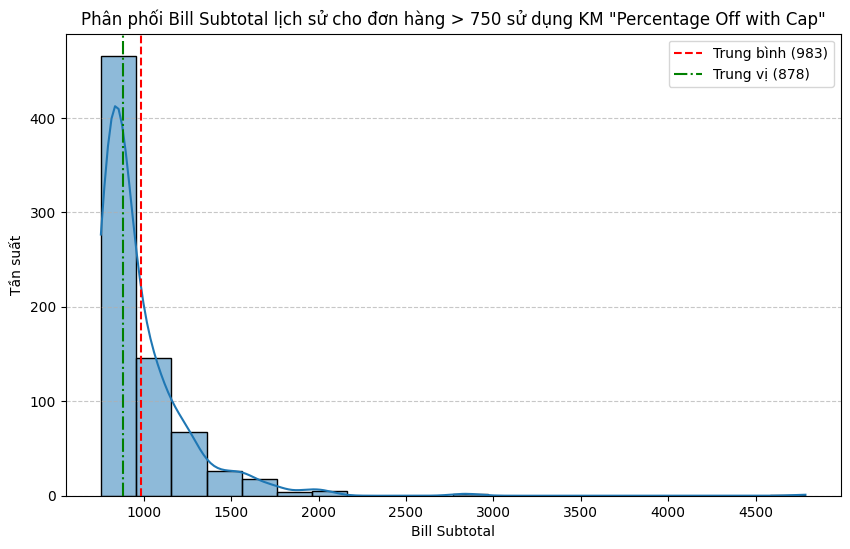


Nhận xét về Bill Subtotal lịch sử cho phân khúc này:
- Biểu đồ trên cho thấy phân phối giá trị Bill Subtotal của các đơn hàng > 750 trong lịch sử có sử dụng KM 'Percentage Off with Cap'.
- Giá trị Bill Subtotal trung bình lịch sử (983.22) được sử dụng làm giá trị giỏ hàng đại diện trong các tính toán mô phỏng hiệu quả cho 7 ngày tới.
- Điều này có nghĩa là chúng ta giả định MỖI đơn hàng trong ước tính của phân khúc này trong 7 ngày tới sẽ có Bill Subtotal bằng 983.22.
- Sự phân tán của Bill Subtotal trong lịch sử cho thấy rằng việc chỉ sử dụng giá trị trung bình là một sự đơn giản hóa.
----------------------------------------------------------------------

--- Mô phỏng Nhiều Kịch bản Percentage/Cap ---
Sử dụng Bill Subtotal trung bình lịch sử (983.22) làm giá trị đại diện cho đơn hàng > 750 sử dụng KM này.
Đang khám phá lưới 6 Percentage Rate và 12 Cap Amount (72 kịch bản).

Cặp KM Cơ sở cho tính Co giãn: 40% off upto 80 Rs.
  Discount Cost trung bình ước tính cho cặp cơ sở: 80.00 Rs.

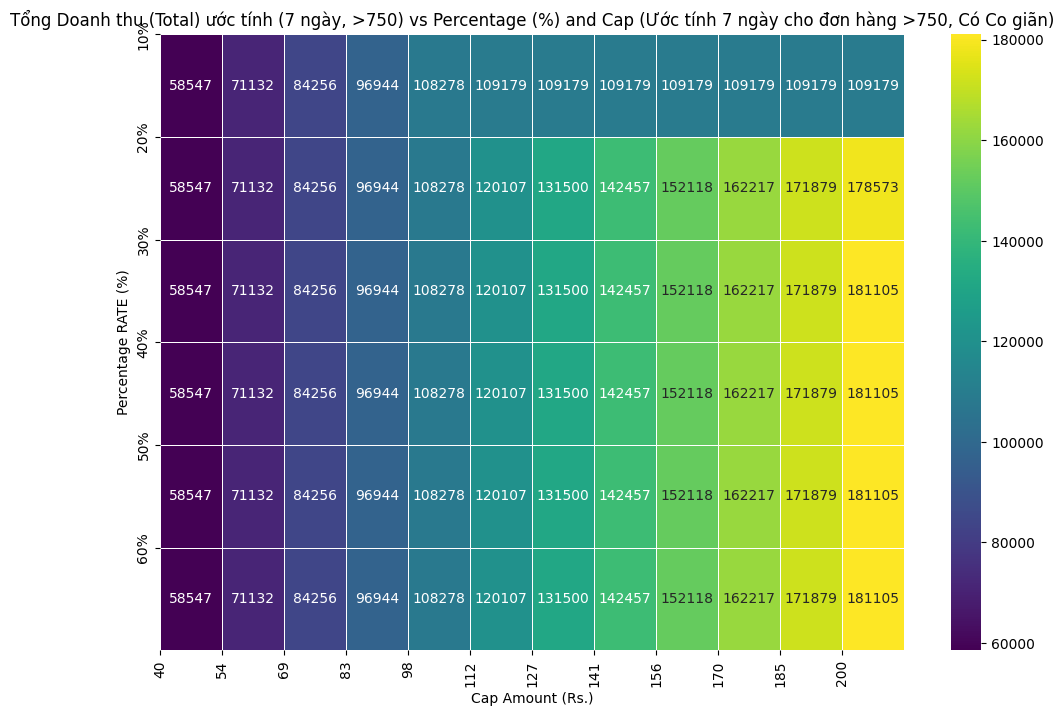


Đang vẽ heatmap cho: Tổng Chi phí Discount ước tính (7 ngày, >750)


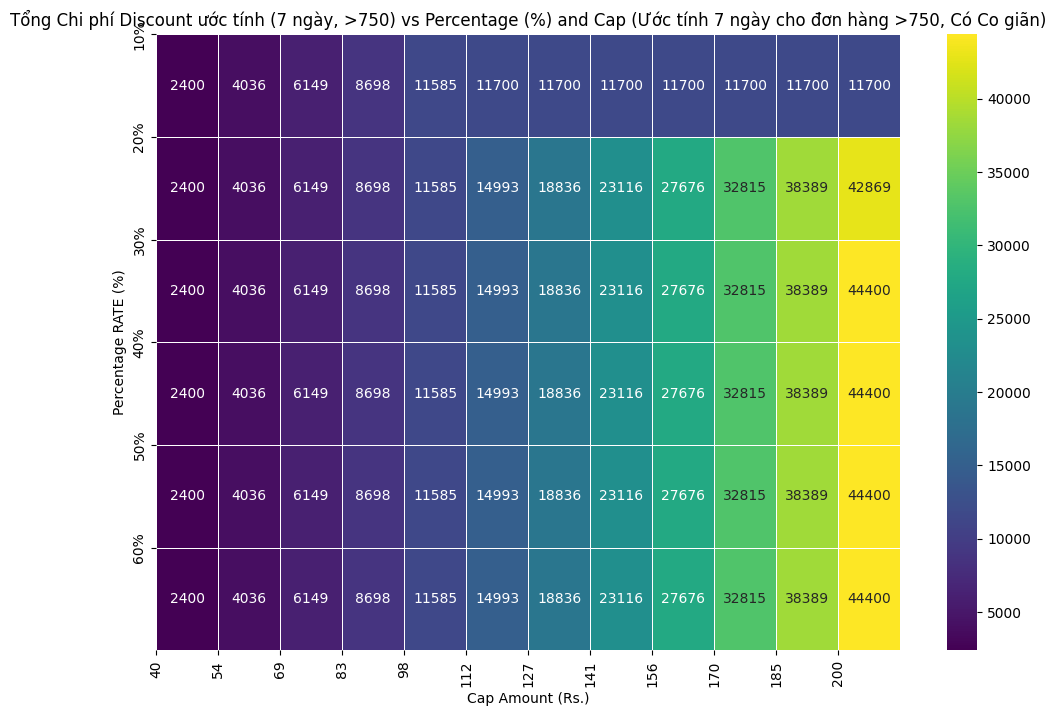


Đang vẽ heatmap cho: Revenue_per_Discount_Cost


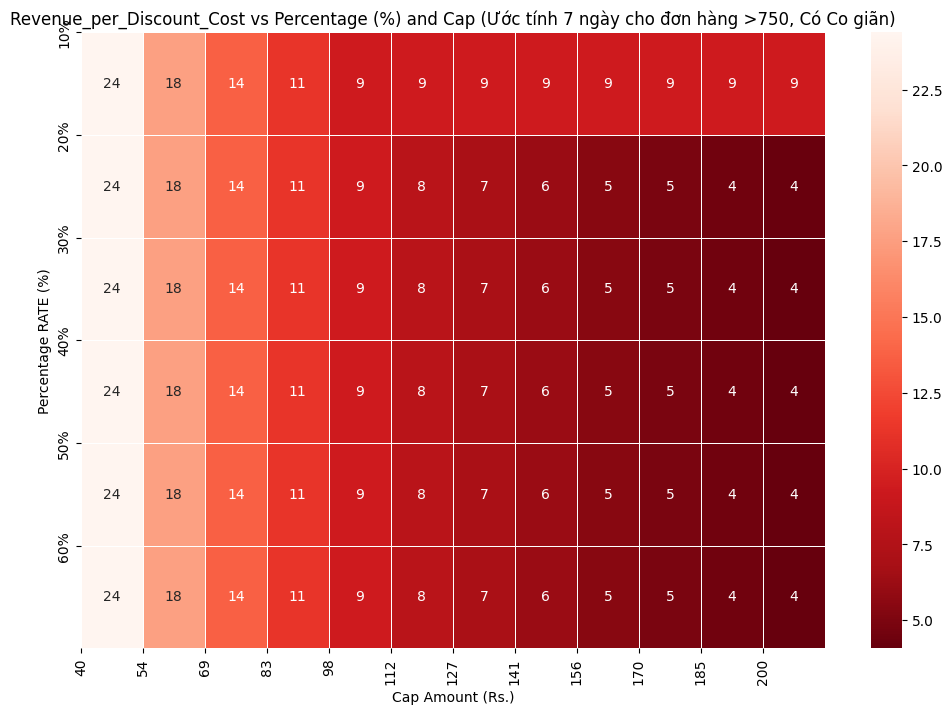


Đang vẽ heatmap cho: Số đơn dự kiến (7 ngày, >750, dùng KM này)


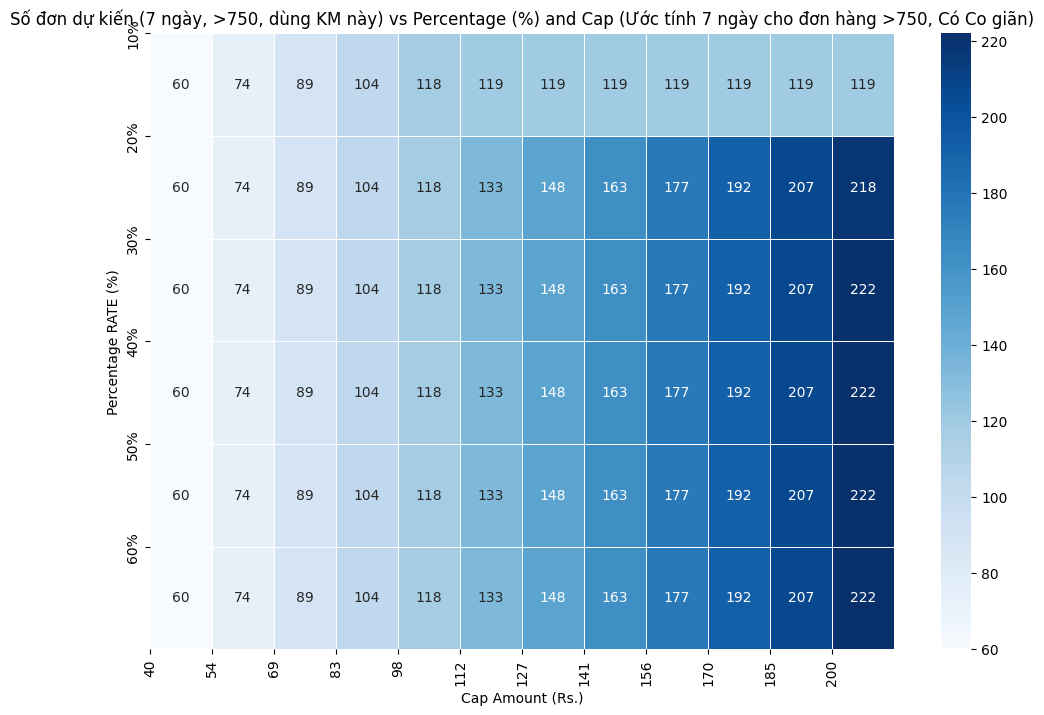


Đang vẽ heatmap cho: Pct_Change_Orders_Est


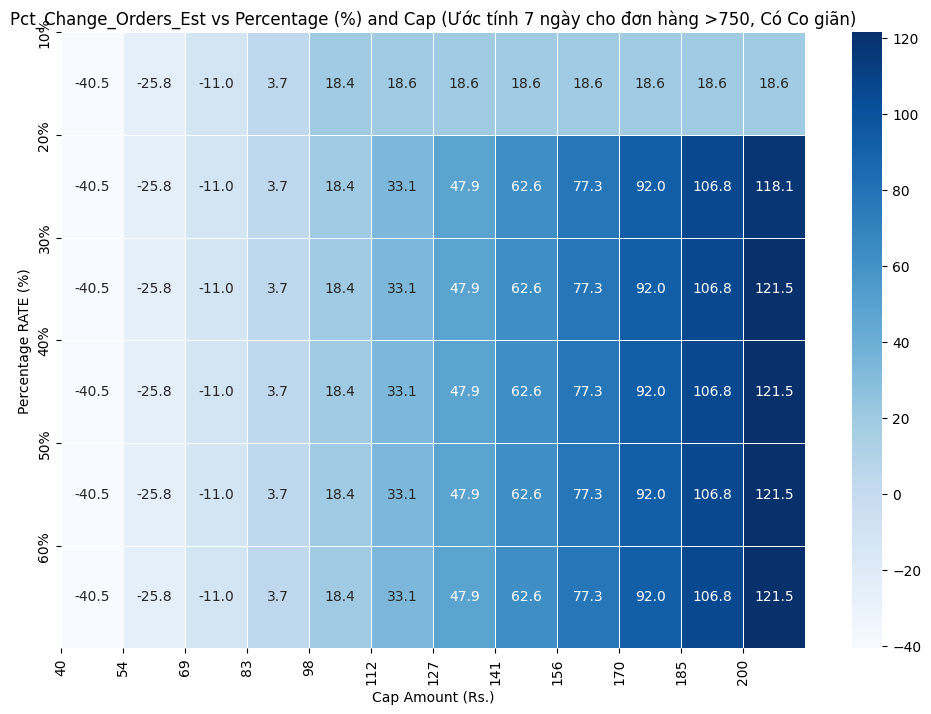


Đang vẽ heatmap cho: Estimated_Avg_Discount_Per_Order


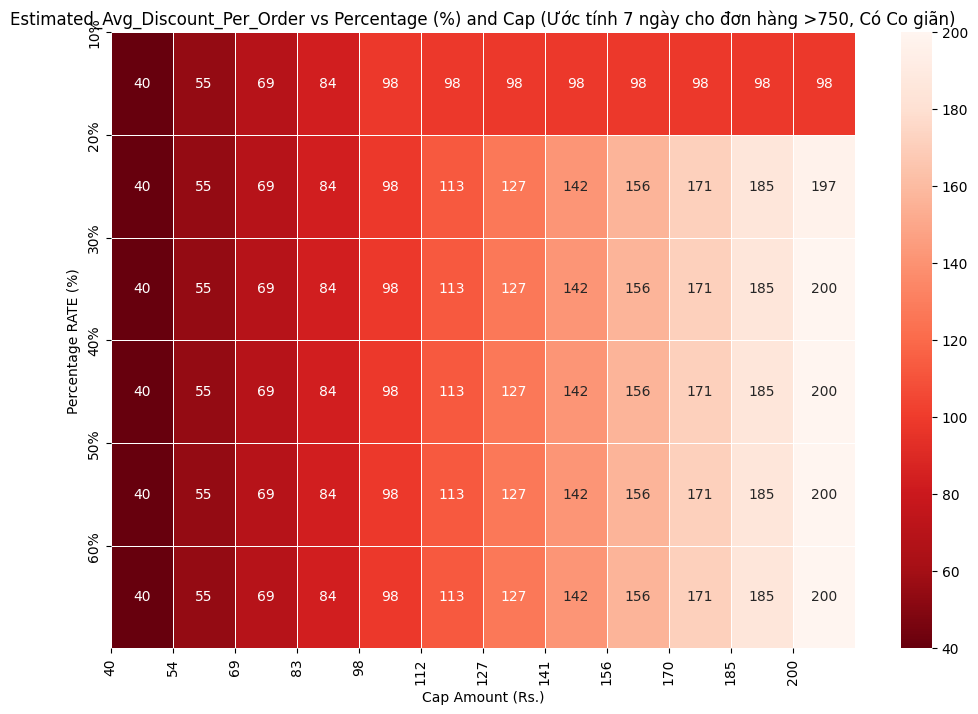


--- Nhận định chung về Kết quả Mô phỏng ---
- Các Heatmap này thể hiện các chỉ số hiệu quả dự kiến cho 7 ngày tới, CHỈ ÁP DỤNG cho nhóm đơn hàng có Bill Subtotal > 750 VÀ sử dụng loại KM 'Percentage Off with Cap', CÓ TÍNH ĐẾN CO GIÃN SỐ ĐƠN HÀNG dựa trên sự thay đổi tỷ lệ giảm giá so với cặp cơ sở (40% off upto 80 Rs.).
- Giá trị Bill Subtotal trung bình lịch sử cho phân khúc này (983.22 Rs.) được sử dụng làm giá trị giỏ hàng đại diện trong mô phỏng.
- Heatmap 'Pct_Change_Orders_Est' và 'Số đơn dự kiến': Cho thấy số lượng đơn hàng dự kiến tăng/giảm như thế nào khi KM hấp dẫn hơn/kém hơn cặp cơ sở.
- Heatmap 'Estimated_Avg_Discount_Per_Order': Cho thấy chi phí discount trung bình trên mỗi đơn hàng tăng/giảm như thế nào.
- Heatmap 'Tổng Doanh thu (Total) ước tính': Phản ánh sự kết hợp của sự thay đổi số đơn hàng và doanh thu trên mỗi đơn hàng.
- Heatmap 'Tổng Chi phí Discount ước tính': Phản ánh sự kết hợp của sự thay đổi số đơn hàng và chi phí discount trên mỗi đơn hàng.
- Heatmap 'Rev

In [ ]:
# --- BẮT ĐẦU PHÂN TÍCH ---
print("--- BẮT ĐẦU PHÂN TÍCH ẢNH HƯỞNG CỦA KHUYẾN MÃI (TẬP TRUNG VÀO ĐƠN HÀNG SUBTOTAL > 1000) ---")

# --- Nạp Data ---
print("\n--- Nạp Dữ liệu ---")
try:
    df = pd.read_csv('50_sample_data.csv')
except UnicodeDecodeError:
    try:
        df = pd.read_csv('50_sample_data.csv', encoding='latin1')
    except Exception as e:
        print(f"Lỗi khi đọc file CSV: {e}")
        df = pd.DataFrame()

if not df.empty:
    df.columns = df.columns.str.strip()
    print(f"Dữ liệu đã được nạp thành công. Số lượng đơn hàng ban đầu: {len(df)}")
else:
    print("Không nạp được dữ liệu. Dừng phân tích.")

# --- Chuẩn bị dữ liệu và Tạo Đặc trưng ---
print("\n--- Chuẩn bị Dữ liệu và Tạo Đặc trưng ---")
if not df.empty:
    if 'Order Placed At' in df.columns:
        if not pd.api.types.is_datetime64_any_dtype(df['Order Placed At']):
            df['Order Placed At'] = pd.to_datetime(df['Order Placed At'], errors='coerce')
            print("Đã chuyển 'Order Placed At' sang datetime.")
        else:
            print("'Order Placed At' đã là datetime.")
        if 'DayofWeek' not in df.columns and not df['Order Placed At'].isnull().all():
            df['DayofWeek'] = df['Order Placed At'].dt.dayofweek
            df['DayofWeekName'] = df['Order Placed At'].dt.day_name()
            print("Đã tạo cột 'DayofWeek' và 'DayofWeekName'.")
        if 'Hour' not in df.columns and not df['Order Placed At'].isnull().all():
            df['Hour'] = df['Order Placed At'].dt.hour
            print("Đã tạo cột 'Hour'.")
        if 'Order Date' not in df.columns and not df['Order Placed At'].isnull().all():
            df['Order Date'] = df['Order Placed At'].dt.date
            df['Order Date'] = pd.to_datetime(df['Order Date'])
            print("Đã tạo cột 'Order Date'.")
    else:
        print("Cảnh báo: Không tìm thấy cột 'Order Placed At'. Bỏ qua tạo đặc trưng thời gian.")

    def clean_discount(text):
        if isinstance(text, str):
            text = text.strip().lower()
            if '%' in text and 'off upto' in text:
                return 'Percentage Off with Cap'
            elif 'flat' in text and 'off' in text:
                return 'Flat Off'
            elif text == 'no discount':
                return 'No Discount'
            elif 'buy' in text and 'get' in text:
                return 'Buy X Get Y'
        return 'Other/Unknown'

    if 'Discount construct' in df.columns:
        df['Discount Category'] = df['Discount construct'].apply(clean_discount)
        print("Đã tạo cột 'Discount Category'.")
    else:
        print("Cảnh báo: Không tìm thấy cột 'Discount construct'. Không thể tạo 'Discount Category'.")
        df['Discount Category'] = 'Unknown'

    discount_cols_numeric = [
        'Restaurant discount (Promo)',
        'Restaurant discount (Flat offs, Freebies & others)',
        'Gold discount',
        'Brand pack discount'
    ]
    valid_cols = [col for col in df.columns if col in discount_cols_numeric]
    if valid_cols:
        for col in valid_cols:
            if col in df.columns and df[col].isnull().any():
                df[col] = df[col].fillna(0)
        df['Total Numerical Discount Cost'] = df[valid_cols].sum(axis=1)
        print("Đã tính 'Total Numerical Discount Cost'.")
    else:
        print("Cảnh báo: Không tìm thấy cột discount số nào để tính 'Total Numerical Discount Cost'. Tạo cột với giá trị 0.")
        df['Total Numerical Discount Cost'] = 0

    def parse_discount_string_fixed(discount_str):
        if not isinstance(discount_str, str):
            return 0.0, 0.0, 0.0
        discount_str = discount_str.strip().lower()
        percentage = 0.0
        cap = 0.0
        flat = 0.0
        if 'upto' in discount_str and '%' in discount_str:
            pct_cap_match = re.search(r'(\d+)% off upto rs\.?([\d\.]+)', discount_str)
            if pct_cap_match:
                try:
                    percentage = float(pct_cap_match.group(1)) / 100.0
                    cap = float(pct_cap_match.group(2))
                    return percentage, cap, 0.0
                except ValueError:
                    pass
        if 'flat' in discount_str and 'off' in discount_str:
            flat_match = re.search(r'flat rs\.?([\d\.]+)\s*off', discount_str)
            if flat_match:
                try:
                    flat = float(flat_match.group(1))
                    return 0.0, 0.0, flat
                except ValueError:
                    pass
        return 0.0, 0.0, 0.0

    if 'Discount construct' in df.columns:
        df[['Discount_Pct', 'Discount_Cap', 'Discount_Flat']] = df['Discount construct'].apply(
            lambda x: pd.Series(parse_discount_string_fixed(x))
        )
        print("Đã tạo các cột 'Discount_Pct', 'Discount_Cap', 'Discount_Flat'.")
    else:
        print("Cảnh báo: Không tìm thấy cột 'Discount construct'. Không thể tạo 'Discount_Pct', 'Discount_Cap', 'Discount_Flat'. Tạo cột với giá trị 0.")
        df[['Discount_Pct', 'Discount_Cap', 'Discount_Flat']] = 0.0

    def count_items_in_order(items_str):
        if not isinstance(items_str, str):
            return 1
        stripped_str = items_str.strip()
        if not stripped_str:
            return 1
        items_list = stripped_str.split(',')
        return len(items_list)

    if 'Items in order' in df.columns:
        df['Num_Distinct_Items'] = df['Items in order'].apply(count_items_in_order)
        print("Đã tạo cột 'Num_Distinct_Items'.")
    else:
        print("Cảnh báo: Không tìm thấy cột 'Items in order'. Tạo cột 'Num_Distinct_Items' với giá trị 1.")
        df['Num_Distinct_Items'] = 1

    numeric_features_to_check = ['Bill subtotal', 'Distance', 'Packaging charges', 'Rating', 'KPT duration (minutes)', 'Rider wait time (minutes)']
    for col in numeric_features_to_check:
        if col in df.columns and df[col].isnull().any():
            if col in ['Bill subtotal', 'Distance', 'Num_Distinct_Items', 'Hour', 'Packaging charges']:
                median_val = df[col].median()
                if not pd.isna(median_val):
                    df[col] = df[col].fillna(median_val)
                    print(f"Đã điền giá trị thiếu cho '{col}' bằng median ({median_val:.2f}).")
                else:
                    default_val = 0
                    df[col] = df[col].fillna(default_val)
                    print(f"Cảnh báo: Cột '{col}' toàn bộ là NaN hoặc không tính được median. Đã điền bằng giá trị mặc định ({default_val}).")
            else:
                df[col] = df[col].fillna(0)
else:
    print("Không có dữ liệu để chuẩn bị đặc trưng.")

print("-" * 70)

# --- Huấn luyện Mô hình Regression dự đoán Bill Subtotal ---
print("\n--- Huấn luyện Mô hình Regression dự đoán Bill Subtotal ---")
model_reg_pipeline = None
if not df.empty and 'Bill subtotal' in df.columns and 'DayofWeek' in df.columns and 'Discount Category' in df.columns:
    cols_for_regression = ['Bill subtotal', 'Discount Category', 'Discount_Pct', 'Discount_Cap', 'Discount_Flat', 'DayofWeek', 'Distance', 'Num_Distinct_Items', 'Hour']
    cols_for_regression = [col for col in cols_for_regression if col in df.columns]
    df_for_reg = df[cols_for_regression].dropna().copy()
    if df_for_reg.empty:
        print("Lỗi: Không còn dòng dữ liệu nào sau khi loại bỏ NaN cho Regression. Không thể huấn luyện mô hình.")
        model_reg_pipeline = None
    else:
        target_regression = df_for_reg['Bill subtotal']
        features_regression = df_for_reg.drop(columns=['Bill subtotal'])
        print(f"Kích thước features_regression sau loại bỏ NaN cho Regression: {features_regression.shape}")
        print(f"Kích thước target_regression sau loại bỏ NaN cho Regression: {target_regression.shape}")
        nan_counts_final = features_regression.isnull().sum()
        if nan_counts_final[nan_counts_final > 0].empty:
            print("Kiểm tra NaN cuối cùng: Không còn giá trị thiếu trong features_regression.")
        else:
            print("Cảnh báo: Vẫn còn giá trị thiếu sau loại bỏ NaN cho Regression. Kiểm tra lại code tiền xử lý.")
            print(nan_counts_final[nan_counts_final > 0])
        if len(features_regression) != len(target_regression) or len(features_regression) == 0:
            print(f"Lỗi: Kích thước features ({len(features_regression)}) và target ({len(target_regression)}) không khớp hoặc rỗng. Không thể huấn luyện mô hình.")
            model_reg_pipeline = None
        else:
            categorical_features_reg = ['Discount Category', 'DayofWeek']
            categorical_features_reg = [col for col in categorical_features_reg if col in features_regression.columns]
            numerical_features_reg = [col for col in features_regression.columns if col not in categorical_features_reg]
            print("\nKiểm tra cột phân loại cho OneHotEncoder...")
            cols_to_remove_from_ohe = []
            for col in categorical_features_reg:
                if features_regression[col].nunique() <= 1:
                    print(f"Cảnh báo: Cột phân loại '{col}' chỉ có 1 hoặc 0 giá trị duy nhất ({features_regression[col].nunique()}). Loại bỏ khỏi OHE.")
                    cols_to_remove_from_ohe.append(col)
                else:
                    features_regression[col] = features_regression[col].astype('category')
                    print(f"Cột '{col}' có {features_regression[col].nunique()} giá trị duy nhất. Giữ lại cho OHE.")
            categorical_features_reg = [col for col in categorical_features_reg if col not in cols_to_remove_from_ohe]
            numerical_features_reg = [col for col in features_regression.columns if col not in categorical_features_reg]
            required_cols = ['Discount Category', 'Discount_Pct', 'Discount_Cap', 'Discount_Flat', 'DayofWeek', 'Distance', 'Num_Distinct_Items', 'Hour']
            required_cols_present = all(col in features_regression.columns for col in required_cols)
            if not required_cols_present:
                print("Lỗi: Một số cột đặc trưng cần thiết bị thiếu sau xử lý NaN. Không thể huấn luyện mô hình.")
                print(f"Cột cần thiết: {required_cols}")
                print(f"Cột đặc trưng có sẵn sau xử lý NaN: {features_regression.columns.tolist()}")
                model_reg_pipeline = None
            else:
                preprocessor_reg = ColumnTransformer(
                    transformers=[
                        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features_reg),
                    ],
                    remainder='passthrough'
                )
                model_reg_pipeline = Pipeline(steps=[
                    ('preprocessor', preprocessor_reg),
                    ('regressor', xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1))
                ])
                print("\nĐang huấn luyện mô hình Regression (XGBoost) trên toàn bộ dữ liệu lịch sử...")
                try:
                    model_reg_pipeline.fit(features_regression, target_regression)
                    print("Đã huấn luyện xong mô hình Regression (XGBoost) trên toàn bộ dữ liệu lịch sử.")
                except Exception as e:
                    print(f"Lỗi trong quá trình huấn luyện mô hình: {e}")
                    model_reg_pipeline = None
else:
    print("Dữ liệu gốc không đủ để huấn luyện mô hình Regression (thiếu cột cần thiết hoặc rỗng sau xử lý NaN).")

print("-" * 70)

# --- Dự báo Tổng số Đơn hàng ---
print("\n--- Sử dụng Dự báo Tổng số Đơn hàng cho 7 ngày tới ---")
forecast_data_orders = {
    '2025-01-25': 161.82,
    '2025-01-26': 184.37,
    '2025-01-27': 120.51,
    '2025-01-28': 124.80,
    '2025-01-29': 144.73,
    '2025-01-30': 151.30,
    '2025-01-31': 163.24,
    '2025-02-01': 28.35
}
forecast_orders_series_daily = pd.Series(forecast_data_orders)
forecast_orders_series_daily.index = pd.to_datetime(forecast_orders_series_daily.index)
forecast_orders_7days = pd.Series(dtype=float)
if not forecast_orders_series_daily.empty:
    forecast_start_date = forecast_orders_series_daily.index.min()
    forecast_end_date = forecast_start_date + pd.Timedelta(days=6)
    forecast_orders_7days = forecast_orders_series_daily.loc[forecast_start_date : forecast_end_date].copy()
    if len(forecast_orders_7days) < 7:
        print(f"Cảnh báo: Dữ liệu dự báo cung cấp ít hơn 7 ngày bắt đầu từ {forecast_start_date.strftime('%Y-%m-%d')}. Chỉ sử dụng {len(forecast_orders_7days)} ngày có sẵn.")
else:
    print("\nKhông có dữ liệu dự báo Daily_Orders ban đầu.")
forecast_orders_7days_rounded = forecast_orders_7days.apply(lambda x: max(0, round(x)))
if not forecast_orders_7days_rounded.empty:
    print("\nDữ liệu Dự báo Daily_Orders cho 7 ngày tới (được cung cấp, làm tròn số đơn):")
    print(forecast_orders_7days_rounded.to_string())
else:
    print("\nKhông có dữ liệu dự báo Daily_Orders hợp lệ cho 7 ngày tới.")

print("-" * 70)

# --- Tỷ lệ sử dụng KM 'Percentage Off with Cap' ---
print(f"\n--- Tính toán Tỷ lệ sử dụng KM 'Percentage Off with Cap' cho đơn hàng Bill Subtotal > 1000 ---")
subtotal_threshold = 750
weekly_usage_rate_promo_high_subtotal_dict = {}
if not df.empty and 'Bill subtotal' in df.columns and 'Discount Category' in df.columns and 'DayofWeek' in df.columns:
    df_high_subtotal = df[df['Bill subtotal'] > subtotal_threshold].copy()
    if df_high_subtotal.empty:
        print(f"Cảnh báo: Không tìm thấy đơn hàng nào có Bill Subtotal > {subtotal_threshold} trong dữ liệu lịch sử. Tỷ lệ sử dụng sẽ là 0.")
    else:
        total_high_subtotal_orders_weekly = df_high_subtotal.groupby('DayofWeek')['Order ID'].count().reset_index()
        total_high_subtotal_orders_weekly.rename(columns={'Order ID': 'Total_High_Subtotal_Orders'}, inplace=True)
        promo_high_subtotal_orders_weekly = df_high_subtotal[
            df_high_subtotal['Discount Category'] == target_promo_category
        ].groupby('DayofWeek')['Order ID'].count().reset_index()
        promo_high_subtotal_orders_weekly.rename(columns={'Order ID': 'Promo_High_Subtotal_Orders'}, inplace=True)
        weekly_usage_data_high_subtotal = pd.merge(
            promo_high_subtotal_orders_weekly,
            total_high_subtotal_orders_weekly,
            on='DayofWeek',
            how='right'
        )
        weekly_usage_data_high_subtotal['Promo_High_Subtotal_Orders'] = weekly_usage_data_high_subtotal['Promo_High_Subtotal_Orders'].fillna(0)
        weekly_usage_data_high_subtotal['Total_High_Subtotal_Orders'] = weekly_usage_data_high_subtotal['Total_High_Subtotal_Orders'].fillna(0)
        weekly_usage_data_high_subtotal['Weekly_Usage_Rate_High_Subtotal'] = np.where(
            weekly_usage_data_high_subtotal['Total_High_Subtotal_Orders'] > 0,
            weekly_usage_data_high_subtotal['Promo_High_Subtotal_Orders'] / weekly_usage_data_high_subtotal['Total_High_Subtotal_Orders'],
            0
        )
        weekly_usage_rate_promo_high_subtotal_dict = weekly_usage_data_high_subtotal.set_index('DayofWeek')['Weekly_Usage_Rate_High_Subtotal'].to_dict()
        print(f"\nTỷ lệ sử dụng KM '{target_promo_category}' trên tổng số đơn hàng Bill Subtotal > {subtotal_threshold} theo Ngày trong tuần (dạng dictionary):")
        print(weekly_usage_rate_promo_high_subtotal_dict)
else:
    print("Dữ liệu gốc không đủ để tính tỷ lệ sử dụng theo ngày cho đơn > 750.")

print("-" * 70)

# --- Trực quan hóa Bill Subtotal lịch sử ---
print(f"\n--- Phân tích và Trực quan hóa Bill Subtotal lịch sử ---")
avg_bill_subtotal_high_subtotal_promo = np.nan
if not df.empty and 'Bill subtotal' in df.columns and 'Discount Category' in df.columns:
    df_high_subtotal_promo = df[
        (df['Bill subtotal'] > subtotal_threshold) &
        (df['Discount Category'] == target_promo_category)
    ].copy()
    if df_high_subtotal_promo.empty:
        print(f"Không tìm thấy đơn hàng nào có Bill Subtotal > {subtotal_threshold} VÀ sử dụng KM '{target_promo_category}' trong dữ liệu lịch sử.")
        print("Không có dữ liệu để trực quan hóa hoặc tính Bill Subtotal trung bình lịch sử cho phân khúc này.")
        avg_bill_subtotal_high_subtotal_promo = np.nan
    else:
        avg_bill_subtotal_high_subtotal_promo = df_high_subtotal_promo['Bill subtotal'].mean()
        median_bill_subtotal_high_subtotal_promo = df_high_subtotal_promo['Bill subtotal'].median()
        count_high_subtotal_promo = len(df_high_subtotal_promo)
        print(f"Số lượng đơn hàng lịch sử (> {subtotal_threshold}, dùng '{target_promo_category}'): {count_high_subtotal_promo}")
        print(f"Bill Subtotal trung bình lịch sử cho phân khúc này: {avg_bill_subtotal_high_subtotal_promo:.2f}")
        print(f"Bill Subtotal trung vị lịch sử cho phân khúc này: {median_bill_subtotal_high_subtotal_promo:.2f}")
        print("\nThống kê mô tả Bill Subtotal cho phân khúc này:")
        print(df_high_subtotal_promo['Bill subtotal'].describe().round(2))
        plt.figure(figsize=(10, 6))
        sns.histplot(df_high_subtotal_promo['Bill subtotal'], kde=True, bins=20)
        plt.axvline(avg_bill_subtotal_high_subtotal_promo, color='r', linestyle='--', label=f'Trung bình ({avg_bill_subtotal_high_subtotal_promo:.0f})')
        plt.axvline(median_bill_subtotal_high_subtotal_promo, color='g', linestyle='-.', label=f'Trung vị ({median_bill_subtotal_high_subtotal_promo:.0f})')
        plt.title(f'Phân phối Bill Subtotal lịch sử cho đơn hàng > {subtotal_threshold} sử dụng KM "{target_promo_category}"')
        plt.xlabel('Bill Subtotal')
        plt.ylabel('Tần suất')
        plt.legend()
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()
        print("\nNhận xét về Bill Subtotal lịch sử cho phân khúc này:")
        print(f"- Biểu đồ trên cho thấy phân phối giá trị Bill Subtotal của các đơn hàng > {subtotal_threshold} trong lịch sử có sử dụng KM '{target_promo_category}'.")
        print(f"- Giá trị Bill Subtotal trung bình lịch sử ({avg_bill_subtotal_high_subtotal_promo:.2f}) được sử dụng làm giá trị giỏ hàng đại diện trong các tính toán mô phỏng hiệu quả cho 7 ngày tới.")
        print(f"- Điều này có nghĩa là chúng ta giả định MỖI đơn hàng trong ước tính của phân khúc này trong 7 ngày tới sẽ có Bill Subtotal bằng {avg_bill_subtotal_high_subtotal_promo:.2f}.")
        print("- Sự phân tán của Bill Subtotal trong lịch sử cho thấy rằng việc chỉ sử dụng giá trị trung bình là một sự đơn giản hóa.")
else:
    print("Dữ liệu gốc không đủ để phân tích Bill Subtotal lịch sử cho nhóm > 1000 sử dụng KM Percentage Off.")
    avg_bill_subtotal_high_subtotal_promo = np.nan

print("-" * 70)

# --- Mô phỏng Nhiều Kịch bản Percentage/Cap ---
print(f"\n--- Mô phỏng Nhiều Kịch bản Percentage/Cap ---")
simulation_heatmap_data = pd.DataFrame()
if pd.isna(avg_bill_subtotal_high_subtotal_promo) or avg_bill_subtotal_high_subtotal_promo <= 0:
    print(f"Lỗi: Không tính được Bill Subtotal trung bình lịch sử hợp lệ cho đơn hàng > {subtotal_threshold} sử dụng KM '{target_promo_category}'. Không thể tiến hành mô phỏng.")
    simulation_heatmap_data = pd.DataFrame()
else:
    bill_subtotal_representative = avg_bill_subtotal_high_subtotal_promo
    print(f"Sử dụng Bill Subtotal trung bình lịch sử ({bill_subtotal_representative:.2f}) làm giá trị đại diện cho đơn hàng > {subtotal_threshold} sử dụng KM này.")
    pct_range_explore_grid = np.linspace(0.1, 0.6, 6)
    cap_range_explore_grid = np.linspace(40, 200, 12)
    print(f"Đang khám phá lưới {len(pct_range_explore_grid)} Percentage Rate và {len(cap_range_explore_grid)} Cap Amount ({len(pct_range_explore_grid) * len(cap_range_explore_grid)} kịch bản).")
    baseline_pct = 0.40
    baseline_cap = 80.0
    baseline_avg_discount = min(bill_subtotal_representative * baseline_pct, baseline_cap)
    baseline_avg_discount = max(0, baseline_avg_discount)
    baseline_discount_rate = baseline_avg_discount / bill_subtotal_representative if bill_subtotal_representative > 0 else 0
    print(f"\nCặp KM Cơ sở cho tính Co giãn: {int(baseline_pct*100)}% off upto {int(baseline_cap)} Rs.")
    print(f"  Discount Cost trung bình ước tính cho cặp cơ sở: {baseline_avg_discount:.2f} Rs.")
    print(f"  Tỷ lệ giảm giá cơ sở (Discount Cost / Subtotal): {baseline_discount_rate:.4f} ({baseline_discount_rate:.1%})")
    total_estimated_promo_high_subtotal_orders_7days_baseline = 0
    if not forecast_orders_7days_rounded.empty and weekly_usage_rate_promo_high_subtotal_dict:
        estimated_promo_high_subtotal_orders_7days_list = []
        for forecast_date, total_forecast_orders_day in forecast_orders_7days_rounded.items():
            day_of_week_forecast = forecast_date.dayofweek
            rate = weekly_usage_rate_promo_high_subtotal_dict.get(day_of_week_forecast, 0)
            orders_day = total_forecast_orders_day * rate
            estimated_promo_high_subtotal_orders_7days_list.append(orders_day)
        total_estimated_promo_high_subtotal_orders_7days_baseline = max(0, round(np.sum(estimated_promo_high_subtotal_orders_7days_list)))
    print(f"\nƯớc tính TỔNG số đơn hàng (7 ngày, >{subtotal_threshold}, dùng KM này) BAN ĐẦU (trước Co giãn): {total_estimated_promo_high_subtotal_orders_7days_baseline}")
    if total_estimated_promo_high_subtotal_orders_7days_baseline == 0:
        print("Số đơn hàng dự kiến ban đầu là 0. Không thể tiến hành mô phỏng có tính đến co giãn.")
        simulation_heatmap_data = pd.DataFrame()
    else:
        ped_absolute = 0.81
        print(f"Sử dụng Giá trị tuyệt đối Co giãn theo giá (PED): {ped_absolute}")
        if 'Packaging charges' in df.columns and not df['Packaging charges'].isnull().any():
            avg_packaging_per_order_hist = df['Packaging charges'].mean()
        else:
            print("Cảnh báo: Cột 'Packaging charges' không khả dụng hoặc chứa NaN. Sử dụng 0 cho phí đóng gói.")
            avg_packaging_per_order_hist = 0.0
        heatmap_data_list = []
        for pct in pct_range_explore_grid:
            for cap in cap_range_explore_grid:
                current_avg_discount = min(bill_subtotal_representative * pct, cap)
                current_avg_discount = max(0, current_avg_discount)
                current_discount_rate = current_avg_discount / bill_subtotal_representative if bill_subtotal_representative > 0 else 0
                if baseline_discount_rate > 0:
                    pct_change_discount_rate = ((current_discount_rate - baseline_discount_rate) / baseline_discount_rate) * 100
                elif current_discount_rate == 0:
                    pct_change_discount_rate = 0
                else:
                    pct_change_discount_rate = np.inf
                if np.isfinite(pct_change_discount_rate):
                    pct_change_orders = pct_change_discount_rate * ped_absolute
                elif pct_change_discount_rate == np.inf:
                    pct_change_orders = np.inf
                else:
                    pct_change_orders = 0
                if np.isfinite(pct_change_orders):
                    total_estimated_promo_high_subtotal_orders_7days_elastic = total_estimated_promo_high_subtotal_orders_7days_baseline * (1 + (pct_change_orders / 100))
                elif pct_change_orders == np.inf:
                    total_estimated_promo_high_subtotal_orders_7days_elastic = np.inf
                else:
                    total_estimated_promo_high_subtotal_orders_7days_elastic = total_estimated_promo_high_subtotal_orders_7days_baseline
                if np.isfinite(total_estimated_promo_high_subtotal_orders_7days_elastic):
                    total_estimated_promo_high_subtotal_orders_7days_elastic = max(0, round(total_estimated_promo_high_subtotal_orders_7days_elastic))
                current_avg_total_per_order = bill_subtotal_representative - current_avg_discount + avg_packaging_per_order_hist
                if np.isfinite(total_estimated_promo_high_subtotal_orders_7days_elastic):
                    total_subtotal_est_7days = bill_subtotal_representative * total_estimated_promo_high_subtotal_orders_7days_elastic
                    total_discount_est_7days = current_avg_discount * total_estimated_promo_high_subtotal_orders_7days_elastic
                    total_revenue_est_7days = current_avg_total_per_order * total_estimated_promo_high_subtotal_orders_7days_elastic
                else:
                    total_subtotal_est_7days = np.inf if bill_subtotal_representative > 0 else 0
                    total_discount_est_7days = np.inf if current_avg_discount > 0 else 0
                    total_revenue_est_7days = np.inf if current_avg_total_per_order > 0 else 0
                revenue_per_discount_metric = np.nan
                if total_discount_est_7days > 0 and total_discount_est_7days != np.inf:
                    if total_revenue_est_7days != np.inf:
                        revenue_per_discount_metric = total_revenue_est_7days / total_discount_est_7days
                    else:
                        revenue_per_discount_metric = np.inf
                elif total_discount_est_7days == 0 and total_revenue_est_7days > 0:
                    revenue_per_discount_metric = np.inf
                elif total_discount_est_7days == 0 and total_revenue_est_7days == 0:
                    revenue_per_discount_metric = np.nan
                elif total_discount_est_7days == np.inf:
                    revenue_per_discount_metric = np.nan
                heatmap_data_list.append({
                    'Pct_Rate': pct,
                    'Cap': cap,
                    'Bill_Subtotal_Used': bill_subtotal_representative,
                    'Baseline_Discount_Rate': baseline_discount_rate,
                    'Current_Discount_Rate': current_discount_rate,
                    'Pct_Change_Discount_Rate': pct_change_discount_rate,
                    'Pct_Change_Orders_Est': pct_change_orders,
                    f'Số đơn dự kiến (7 ngày, >{subtotal_threshold}, dùng KM này)': total_estimated_promo_high_subtotal_orders_7days_elastic,
                    f'Tổng Bill Subtotal ước tính (7 ngày, >{subtotal_threshold})': total_subtotal_est_7days,
                    f'Tổng Chi phí Discount ước tính (7 ngày, >{subtotal_threshold})': total_discount_est_7days,
                    f'Tổng Doanh thu (Total) ước tính (7 ngày, >{subtotal_threshold})': total_revenue_est_7days,
                    'Revenue_per_Discount_Cost': revenue_per_discount_metric,
                    'Estimated_Avg_Discount_Per_Order': current_avg_discount
                })
                simulation_heatmap_data = pd.DataFrame(heatmap_data_list)
                print("\nĐã hoàn tất tính toán cho lưới kịch bản (có tính đến co giãn). Sẵn sàng vẽ heatmap.")

print("-" * 70)

# --- Trực quan hóa Kết quả Mô phỏng (Heatmaps) ---
print("\n--- Trực quan hóa Kết quả Mô phỏng (Heatmaps) ---")
if simulation_heatmap_data is not None and not simulation_heatmap_data.empty:
    simulation_heatmap_data = simulation_heatmap_data.sort_values(by=['Pct_Rate', 'Cap'])
    print("\nBảng kết quả mô phỏng cho các cặp Pct/Cap trong lưới (chỉ hiển thị một vài cột chính):")
    cols_to_display = [
        'Pct_Rate', 'Cap',
        'Bill_Subtotal_Used',
        'Current_Discount_Rate',
        'Estimated_Avg_Discount_Per_Order',
        'Pct_Change_Discount_Rate',
        'Pct_Change_Orders_Est',
        f'Số đơn dự kiến (7 ngày, >{subtotal_threshold}, dùng KM này)',
        f'Tổng Doanh thu (Total) ước tính (7 ngày, >{subtotal_threshold})',
        f'Tổng Chi phí Discount ước tính (7 ngày, >{subtotal_threshold})',
        'Revenue_per_Discount_Cost'
    ]
    cols_to_display = [col for col in cols_to_display if col in simulation_heatmap_data.columns]
    display_df = simulation_heatmap_data[cols_to_display].copy()
    if 'Pct_Change_Discount_Rate' in display_df.columns:
        display_df['Pct_Change_Discount_Rate'] = display_df['Pct_Change_Discount_Rate'].apply(lambda x: f'{x:,.1f}%' if np.isfinite(x) else 'inf')
    if 'Pct_Change_Orders_Est' in display_df.columns:
        display_df['Pct_Change_Orders_Est'] = display_df['Pct_Change_Orders_Est'].apply(lambda x: f'{x:,.1f}%' if np.isfinite(x) else 'inf')
    if 'Current_Discount_Rate' in display_df.columns:
        display_df['Current_Discount_Rate'] = display_df['Current_Discount_Rate'].apply(lambda x: f'{x:,.1%}')
    pd.options.display.float_format = '{:,.2f}'.format
    print(display_df.to_string())
    pd.options.display.float_format = None
    heatmap_metrics_to_plot = [
        f'Tổng Doanh thu (Total) ước tính (7 ngày, >{subtotal_threshold})',
        f'Tổng Chi phí Discount ước tính (7 ngày, >{subtotal_threshold})',
        'Revenue_per_Discount_Cost',
        f'Số đơn dự kiến (7 ngày, >{subtotal_threshold}, dùng KM này)',
        'Pct_Change_Orders_Est',
        'Estimated_Avg_Discount_Per_Order'
    ]
    avg_subtotal_used_in_simulation = np.nan
    if 'Bill_Subtotal_Used' in simulation_heatmap_data.columns and not simulation_heatmap_data.empty:
        avg_subtotal_used_in_simulation = simulation_heatmap_data['Bill_Subtotal_Used'].iloc[0]
    baseline_km_label = f"{int(baseline_pct*100)}% off upto {int(baseline_cap)} Rs."
    baseline_discount_rate_used = np.nan
    if 'Baseline_Discount_Rate' in simulation_heatmap_data.columns and not simulation_heatmap_data.empty:
        baseline_discount_rate_used = simulation_heatmap_data['Baseline_Discount_Rate'].iloc[0]
    if not pd.isna(avg_subtotal_used_in_simulation):
        print(f"\n--- Cơ sở Mô phỏng (Có tính đến Co giãn) ---")
        print(f"  Bill Subtotal Trung bình Lịch sử được sử dụng: {avg_subtotal_used_in_simulation:.2f} Rs.")
        print(f"  Cặp KM Cơ sở: {baseline_km_label}")
        if not pd.isna(baseline_discount_rate_used):
            print(f"  Tỷ lệ giảm giá cơ sở (Discount Cost / Subtotal): {baseline_discount_rate_used:.4f} ({baseline_discount_rate_used:.1%})")
        print(f"  Giá trị tuyệt đối Co giãn theo giá (PED) được sử dụng: {ped_absolute}")
        print(f"  Số đơn dự kiến ban đầu (trước Co giãn): {total_estimated_promo_high_subtotal_orders_7days_baseline}")
        print("Heatmaps dưới đây thể hiện hiệu quả dự kiến CÓ TÍNH ĐẾN co giãn số đơn hàng dựa trên sự thay đổi tỷ lệ giảm giá.")
    else:
        print("\n--- Không thể xác định thông tin cơ sở cho mô phỏng Co giãn. ---")
    for metric_name in heatmap_metrics_to_plot:
        if metric_name in simulation_heatmap_data.columns:
            print(f"\nĐang vẽ heatmap cho: {metric_name}")
            pivot_table_data = simulation_heatmap_data.pivot_table(
                values=metric_name,
                index='Pct_Rate',
                columns='Cap',
                aggfunc='mean'
            )
            plt.figure(figsize=(12, 8))
            if 'Cost' in metric_name or 'Revenue' in metric_name or 'Subtotal' in metric_name or 'AOV' in metric_name or 'Bill_Subtotal_Used' in metric_name or 'Estimated_Avg_Discount_Per_Order' in metric_name:
                annot_fmt = ",.0f"
            elif 'Revenue_per_Discount_Cost' in metric_name:
                if (pivot_table_data == np.inf).all().all() or (pivot_table_data == 0).all().all() or pivot_table_data.isnull().all().all():
                    annot_fmt = ".0f"
                else:
                    annot_fmt = ".1f"
            elif 'Số đơn dự kiến' in metric_name:
                annot_fmt = ",.0f"
            elif 'Pct_Change_Orders_Est' in metric_name:
                annot_fmt = ".1f"
            else:
                annot_fmt = ".0f"
            cmap = "viridis"
            if 'Cost' in metric_name or 'Estimated_Avg_Discount_Per_Order' in metric_name:
                cmap = "Reds_r"
            elif 'Revenue' in metric_name:
                cmap = "Greens"
            elif 'Revenue_per_Discount_Cost' in metric_name:
                cmap = "plasma"
            elif 'Số đơn dự kiến' in metric_name or 'Pct_Change_Orders_Est' in metric_name:
                cmap = "Blues"
            sns.heatmap(pivot_table_data, annot=True, fmt=annot_fmt, cmap=cmap, linewidths=.5)
            plt.title(f'{metric_name} vs Percentage (%) and Cap (Ước tính 7 ngày cho đơn hàng >{subtotal_threshold}, Có Co giãn)')
            plt.xlabel('Cap Amount (Rs.)')
            plt.ylabel('Percentage RATE (%)')
            plt.yticks(ticks=np.arange(len(pivot_table_data.index)), labels=[f'{p*100:.0f}%' for p in pivot_table_data.index])
            plt.xticks(ticks=np.arange(len(pivot_table_data.columns)), labels=[f'{int(c)}' for c in pivot_table_data.columns])
            plt.show()
        else:
            print(f"Cảnh báo: Chỉ số '{metric_name}' không tìm thấy trong bảng kết quả mô phỏng. Bỏ qua heatmap này.")
    print("\n--- Nhận định chung về Kết quả Mô phỏng ---")
    print(f"- Các Heatmap này thể hiện các chỉ số hiệu quả dự kiến cho 7 ngày tới, CHỈ ÁP DỤNG cho nhóm đơn hàng có Bill Subtotal > {subtotal_threshold} VÀ sử dụng loại KM 'Percentage Off with Cap', CÓ TÍNH ĐẾN CO GIÃN SỐ ĐƠN HÀNG dựa trên sự thay đổi tỷ lệ giảm giá so với cặp cơ sở ({baseline_km_label}).")
    print(f"- Giá trị Bill Subtotal trung bình lịch sử cho phân khúc này ({avg_subtotal_used_in_simulation:.2f} Rs.) được sử dụng làm giá trị giỏ hàng đại diện trong mô phỏng.")
    print("- Heatmap 'Pct_Change_Orders_Est' và 'Số đơn dự kiến': Cho thấy số lượng đơn hàng dự kiến tăng/giảm như thế nào khi KM hấp dẫn hơn/kém hơn cặp cơ sở.")
    print("- Heatmap 'Estimated_Avg_Discount_Per_Order': Cho thấy chi phí discount trung bình trên mỗi đơn hàng tăng/giảm như thế nào.")
    print("- Heatmap 'Tổng Doanh thu (Total) ước tính': Phản ánh sự kết hợp của sự thay đổi số đơn hàng và doanh thu trên mỗi đơn hàng.")
    print("- Heatmap 'Tổng Chi phí Discount ước tính': Phản ánh sự kết hợp của sự thay đổi số đơn hàng và chi phí discount trên mỗi đơn hàng.")
    print("- Heatmap 'Revenue_per_Discount_Cost': Là tỷ lệ giữa Doanh thu và Chi phí. Cho biết hiệu quả chi phí.")
    print(f"- **Quan sát từ heatmap Revenue_per_Discount_Cost:** Kết quả hiện tại cho thấy rằng, với PED = {ped_absolute}, sự gia tăng số lượng đơn hàng khi tăng Percentage/Cap không đủ để bù đắp cho sự gia tăng chi phí discount trên mỗi đơn, khiến hiệu quả chi phí giảm xuống.")
    print("- Mức 'Tốt nhất' phụ thuộc vào mục tiêu kinh doanh bạn ưu tiên cho phân khúc đơn hàng Bill Subtotal > 1000.")
    print("- **NHỮNG GIẢ ĐỊNH CẦN CÂN NHẮC RẤT KỸ:**")
    print(f"  - Giá trị Co giãn theo giá (PED = {ped_absolute}) là chính xác và áp dụng cho sự thay đổi TỶ LỆ GIẢM GIÁ của KM Percentage Off with Cap trên phân khúc Bill Subtotal > {subtotal_threshold}.")
    print(f"  - Bill Subtotal trung bình của đơn hàng (> {subtotal_threshold}, dùng KM này) là cố định ({avg_subtotal_used_in_simulation:.2f} Rs.) và không thay đổi theo mức KM.")
    print("- Độ chính xác của các giả định này ảnh hưởng lớn đến kết quả mô phỏng.")
else:
    print("\nKhông thể vẽ heatmap vì DataFrame kết quả mô phỏng rỗng.")
print("-" * 70)
print("\n--- KẾT THÚC PHÂN TÍCH ---")

# Xem > 750

--- BƯỚC RIÊNG: TRỰC QUAN HÓA PHÂN PHỐI GIÁ TRỊ ĐƠN HÀNG (TOTAL) (PHIÊN BẢN CHI TIẾT HƠN) ---
Xem hình dạng phân phối với khoảng chia nhỏ hơn, giá trị min/max và các giá trị ngoại lệ.

--- Thống kê mô tả Total trên toàn bộ đơn hàng ---
count    21321.00
mean       682.62
std        465.31
min         52.50
25%        387.45
50%        597.45
75%        837.90
max      12663.00
Name: Total, dtype: float64

=> Giá trị Total NHỎ NHẤT trong dữ liệu: 52.50
=> Giá trị Total LỚN NHẤT trong dữ liệu: 12,663.00

--- Trực quan hóa Phân phối Total trên toàn bộ đơn hàng (Khoảng chia nhỏ hơn) ---


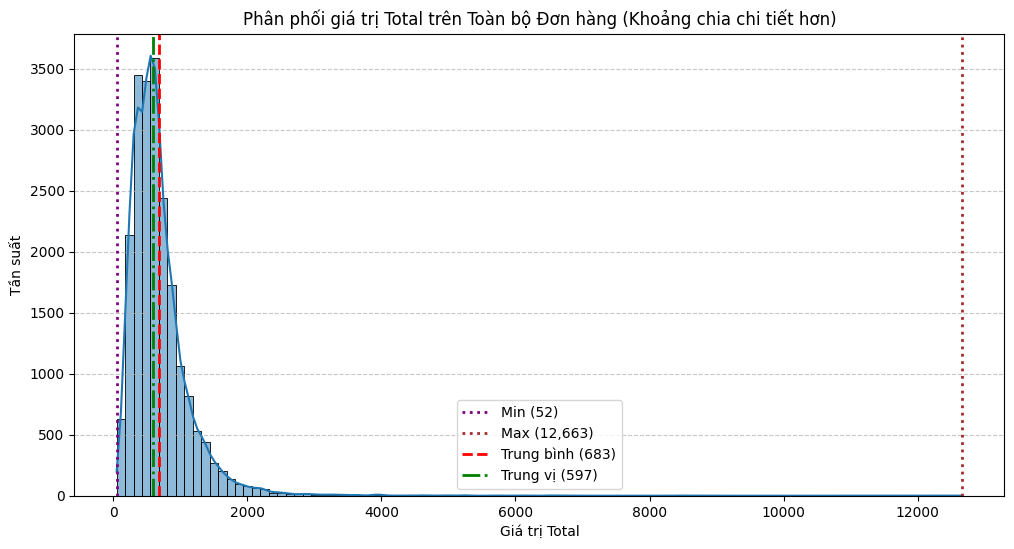

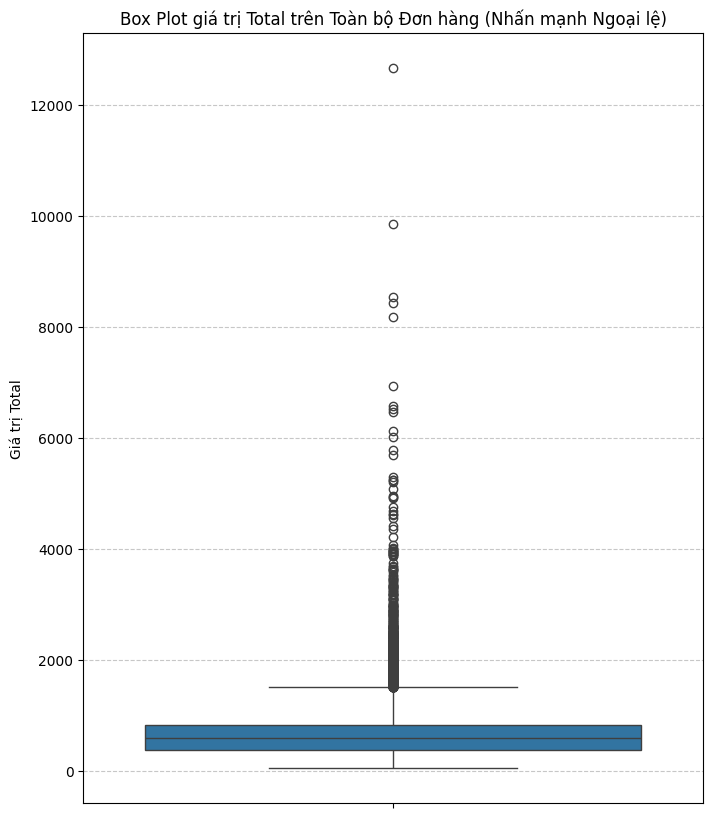


Ngưỡng trên cho biểu đồ tập trung (thường là Q3 + 1.5*IQR): 1,513.57
Số lượng đơn hàng có Total > ngưỡng này: 915


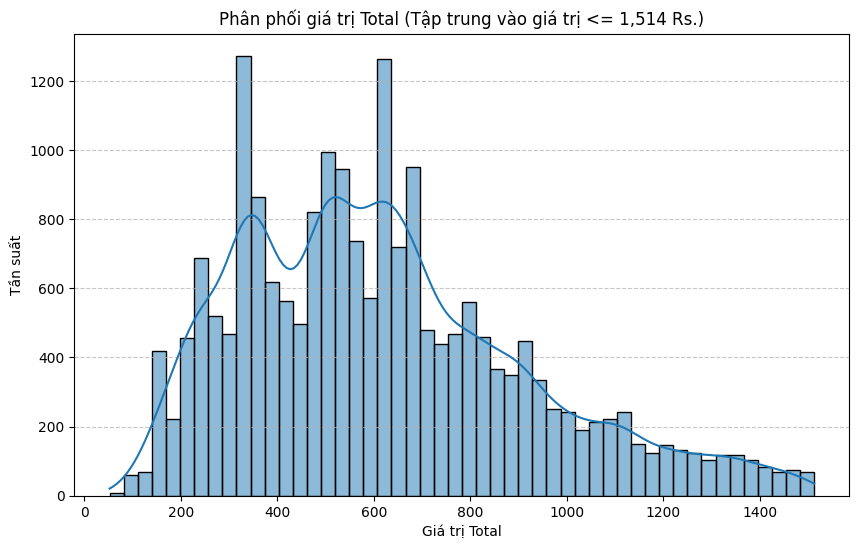


Nhận xét chung về phân phối giá trị Total:
- Biểu đồ Histogram/KDE đầu tiên với khoảng chia chi tiết hơn giúp bạn nhìn rõ hơn hình dạng của phân phối Total.
- Các đường thẳng đánh dấu Giá trị NHỎ NHẤT (52), LỚN NHẤT (12,663), Trung bình (683), và Trung vị (597) giúp xác định phạm vi và trung tâm của dữ liệu.
- Box Plot vẫn là cách tốt nhất để thấy các phân vị và đặc biệt là sự tồn tại của các giá trị ngoại lệ rất cao.
- Biểu đồ tập trung (giới hạn Total <= 1,514 Rs.) giúp nhìn rõ hơn phân phối của phần đông các đơn hàng có giá trị thấp.
- Hiểu rõ phân phối này giúp bạn biết Total trung bình/trung vị điển hình là bao nhiêu, mức độ biến động và sự hiện diện của các đơn hàng giá trị rất cao hoặc rất thấp.
----------------------------------------------------------------------

--- BƯỚC RIÊNG HOÀN THÀNH ---


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- BƯỚC RIÊNG: TRỰC QUAN HÓA PHÂN PHỐI GIÁ TRỊ ĐƠN HÀNG (TOTAL) (PHIÊN BẢN CHI TIẾT HƠN) ---
print("--- BƯỚC RIÊNG: TRỰC QUAN HÓA PHÂN PHỐI GIÁ TRỊ ĐƠN HÀNG (TOTAL) (PHIÊN BẢN CHI TIẾT HƠN) ---")
print("Xem hình dạng phân phối với khoảng chia nhỏ hơn, giá trị min/max và các giá trị ngoại lệ.")

# Giả định df đã được nạp và có cột 'Total'

if not df.empty and 'Total' in df.columns:

    # Loại bỏ các giá trị Total là NaN nếu có, trước khi phân tích phân phối
    df_cleaned_total = df.dropna(subset=['Total']).copy()

    if df_cleaned_total.empty:
         print("Cảnh báo: Cột 'Total' toàn bộ là NaN hoặc rỗng sau khi loại bỏ NaN. Không thể trực quan hóa phân phối.")
    else:

        print("\n--- Thống kê mô tả Total trên toàn bộ đơn hàng ---")
        print(df_cleaned_total['Total'].describe().round(2))

        # Lấy giá trị Min và Max thực tế trong dữ liệu
        min_total = df_cleaned_total['Total'].min()
        max_total = df_cleaned_total['Total'].max()
        mean_total = df_cleaned_total['Total'].mean()
        median_total = df_cleaned_total['Total'].median()

        print(f"\n=> Giá trị Total NHỎ NHẤT trong dữ liệu: {min_total:,.2f}")
        print(f"=> Giá trị Total LỚN NHẤT trong dữ liệu: {max_total:,.2f}")


        print("\n--- Trực quan hóa Phân phối Total trên toàn bộ đơn hàng (Khoảng chia nhỏ hơn) ---")

        # Biểu đồ 1: Histogram/KDE cho toàn bộ Total với bins nhỏ hơn
        # Chọn số lượng bins lớn hơn, ví dụ 100 hoặc 200 tùy vào dải giá trị
        # Hoặc dùng 'auto' để seaborn/matplotlib tự chọn số lượng bins
        # Let's try a fixed larger number for "chia nhỏ hơn"
        num_bins = 100 # Có thể điều chỉnh số này
        if max_total - min_total < num_bins: # Đảm bảo số bins không vượt quá dải giá trị
             num_bins = int(max_total - min_total) if max_total > min_total else 1


        plt.figure(figsize=(12, 6)) # Tăng kích thước biểu đồ
        sns.histplot(df_cleaned_total['Total'], kde=True, bins=num_bins) # Sử dụng số bins mới

        # Thêm các đường thẳng đánh dấu Min, Max, Trung bình, Trung vị
        plt.axvline(min_total, color='purple', linestyle=':', label=f'Min ({min_total:,.0f})', linewidth=2)
        plt.axvline(max_total, color='brown', linestyle=':', label=f'Max ({max_total:,.0f})', linewidth=2)
        plt.axvline(mean_total, color='red', linestyle='--', label=f'Trung bình ({mean_total:,.0f})', linewidth=2)
        plt.axvline(median_total, color='green', linestyle='-.', label=f'Trung vị ({median_total:,.0f})', linewidth=2)
        plt.legend()

        plt.title('Phân phối giá trị Total trên Toàn bộ Đơn hàng (Khoảng chia chi tiết hơn)')
        plt.xlabel('Giá trị Total')
        plt.ylabel('Tần suất')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()

        # Biểu đồ 2: Box Plot để xem các giá trị ngoại lệ (outliers) và phân vị rõ hơn
        # Box plot vẫn là cách tốt nhất để xem các giá trị cực đoan và phân vị
        plt.figure(figsize=(8, 10))
        sns.boxplot(y=df_cleaned_total['Total'])
        plt.title('Box Plot giá trị Total trên Toàn bộ Đơn hàng (Nhấn mạnh Ngoại lệ)')
        plt.ylabel('Giá trị Total')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()

        # Biểu đồ 3: Phân phối tập trung vào các giá trị nhỏ (loại bỏ các giá trị quá lớn)
        # Vẫn giữ biểu đồ này để nhìn rõ phần đông dữ liệu
        Q3 = df_cleaned_total['Total'].quantile(0.75)
        Q1 = df_cleaned_total['Total'].quantile(0.25)
        IQR = Q3 - Q1
        upper_bound_for_viz = Q3 + 1.5 * IQR # Ngưỡng phổ biến để xác định outlier
        # Hoặc bạn có thể chọn một ngưỡng cố định dựa vào trực giác sau khi xem Box Plot
        # upper_bound_for_viz = 1000 # Ví dụ, nếu muốn xem rõ các đơn dưới 1000

        # Đảm bảo ngưỡng không lớn hơn giá trị max thực tế
        upper_bound_for_viz = min(upper_bound_for_viz, max_total)


        print(f"\nNgưỡng trên cho biểu đồ tập trung (thường là Q3 + 1.5*IQR): {upper_bound_for_viz:,.2f}")
        print(f"Số lượng đơn hàng có Total > ngưỡng này: {len(df_cleaned_total[df_cleaned_total['Total'] > upper_bound_for_viz]):,.0f}")

        # Sử dụng số bins tương tự cho biểu đồ tập trung
        num_bins_focused = 50 # Có thể điều chỉnh
        if upper_bound_for_viz - min_total < num_bins_focused:
             num_bins_focused = int(upper_bound_for_viz - min_total) if upper_bound_for_viz > min_total else 1


        plt.figure(figsize=(10, 6))
        sns.histplot(df_cleaned_total[df_cleaned_total['Total'] <= upper_bound_for_viz]['Total'], kde=True, bins=num_bins_focused)
        plt.title(f'Phân phối giá trị Total (Tập trung vào giá trị <= {upper_bound_for_viz:,.0f} Rs.)')
        plt.xlabel('Giá trị Total')
        plt.ylabel('Tần suất')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()


        print("\nNhận xét chung về phân phối giá trị Total:")
        print("- Biểu đồ Histogram/KDE đầu tiên với khoảng chia chi tiết hơn giúp bạn nhìn rõ hơn hình dạng của phân phối Total.")
        print(f"- Các đường thẳng đánh dấu Giá trị NHỎ NHẤT ({min_total:,.0f}), LỚN NHẤT ({max_total:,.0f}), Trung bình ({mean_total:,.0f}), và Trung vị ({median_total:,.0f}) giúp xác định phạm vi và trung tâm của dữ liệu.")
        print("- Box Plot vẫn là cách tốt nhất để thấy các phân vị và đặc biệt là sự tồn tại của các giá trị ngoại lệ rất cao.")
        print(f"- Biểu đồ tập trung (giới hạn Total <= {upper_bound_for_viz:,.0f} Rs.) giúp nhìn rõ hơn phân phối của phần đông các đơn hàng có giá trị thấp.")
        print("- Hiểu rõ phân phối này giúp bạn biết Total trung bình/trung vị điển hình là bao nhiêu, mức độ biến động và sự hiện diện của các đơn hàng giá trị rất cao hoặc rất thấp.")


else:
    print("Dữ liệu gốc rỗng hoặc thiếu cột 'Total'. Bỏ qua trực quan hóa phân phối giá trị đơn hàng.")


print("-" * 70)

print("\n--- BƯỚC RIÊNG HOÀN THÀNH ---")